# Assignment 1: Evaluating Language Technologies
This assignment must be completed in order to be considered for enrollment in the class. If you are already enrolled, failure to complete this assignment will result in your removal from the course.

## Introduction
In this assignment, we will explore different tasks core to the field of NLP. You will implement different evaluation metrics for these tasks and perform analysis of different language
technologies.

Learning objectives:
* Understand the breadth of tasks core to the field of NLP.
* Implement various evaluation methods for core NLP tasks.
* Become familiar with prompting existing LLMs via API calls.
* Identify the limitations of automatic evaluation methods.
* Practice using error analysis to identify where language technologies fail and hypothesizing why they might fail.
* Appreciate things we humans do with language that current language models cannot do.

**Notes:**
* In your solution, keep all code as-is except where it's explicitly mentioned to implement a function.
* Items marked with a star (★) should be answered in markdown text in the notebook. You will include your final notebook as a pdf with your submission.
* Results are written to the `results/` sub-directory as you go, and these are what get autograded.

**Submission:**

When you are done, run `python3 make_submission.py`. It checks that every file the
notebook should have written is present, valid, and actually filled in, then packs
them into `submission.zip` for you to upload to gradescope. Two things go in it:

* All the json files saved inside the `results/` directory. These will be autograded.
* A PDF copy of your completed notebook, titled "HW1.pdf". This is used to grade your answers to the problems marked with a (★), so check that your plots rendered before exporting.

**Setup:**
You will need to download ollama https://ollama.com and install the following models with the commands:

`ollama pull qwen3:8b`

`ollama pull llama3.2:1b`

`ollama pull llama3.2`

`ollama pull gemma3:1b`

`ollama pull gemma3:4b`

You will need about 13GB of storage to download these models. Make sure the ollama binary is in /usr/local/bin/ or you know where it is, so you can call it on the command line.

## Running on Google Colab

Set **Runtime → Change runtime type → GPU**, then run the cell below once. It
clones the repo, installs everything, points your inference cache at Drive so a
disconnect can't throw away work, and starts ollama.

Running on your own machine instead? The cell does nothing — follow the README.

In [2]:
!pip install --upgrade --force-reinstall numpy pandas scipy

  Using cached numpy-2.5.3-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.5-cp313-cp313-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached scipy-1.18.1-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-2.5.3-cp313-cp313-macosx_14_0_arm64.whl (5.4 MB)
Using cached pandas-3.0.5-cp313-cp313-macosx_11_0_arm64.whl (9.9 MB)
Using cached scipy-1.18.1-cp313-cp313-macosx_14_0_arm64.whl (20.5 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1.17.0━━━━━━━━━━━━━ 0/5 [six]
  Attempting uninstall: numpy━━━━━━━━━━━━━━━━━━━━━ 0/5 [six]
    Found existing installation: numpy 2.5.3━━━━━━ 0/5 [si

In [3]:
# Colab setup. On a local machine this cell is a no-op.
import sys

if "google.colab" in sys.modules:
    import os, subprocess, time

    STUDENT_REPO = "https://github.com/zinengtang/cs183-fall26-a1.git"
    DRIVE_DIR = "/content/drive/MyDrive/cs183-a1"

    # 1. code and data, since opening a notebook from GitHub brings only the notebook
    if not os.path.exists("/content/repo"):
        subprocess.run(["git", "clone", "-q", STUDENT_REPO, "/content/repo"], check=True)
    os.chdir("/content/repo")

    # 2. dependencies (ffmpeg is already on Colab). Capture rather than -q: a bare
    #    CalledProcessError tells you nothing about which package refused to install.
    installed = subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"],
                               capture_output=True, text=True)
    if installed.returncode != 0:
        print(installed.stdout[-2000:])
        print(installed.stderr[-2000:])
        raise RuntimeError("pip install failed -- see the output above for which package and why")

    # 3. keep generations and results on Drive -- the runtime's own disk does not
    #    survive a disconnect, and re-running inference costs far more than this does
    from google.colab import drive
    drive.mount("/content/drive")
    for sub in ("inference_cache", "results"):
        os.makedirs(f"{DRIVE_DIR}/{sub}", exist_ok=True)
        subprocess.run(["rm", "-rf", sub], check=True)
        os.symlink(f"{DRIVE_DIR}/{sub}", sub)

    # 4. ollama. Colab has no systemd, so the installer cannot start the server for us.
    #    Only the four small models are pulled here. The 5.2GB judge model that Part 4
    #    needs is pulled at Part 4, so Parts 1-3 are not stuck behind that download.
    #    The installer unpacks a .tar.zst and exits with an error if zstd is missing,
    #    which it is on Colab. There is no .tgz build to fall back to any more.
    if subprocess.run(["apt-get", "install", "-y", "-qq", "zstd"]).returncode != 0:
        subprocess.run(["apt-get", "update", "-qq"], check=False)
        subprocess.run(["apt-get", "install", "-y", "-qq", "zstd"], check=True)

    installer = subprocess.run("curl -fsSL https://ollama.com/install.sh | sh",
                               shell=True, capture_output=True, text=True)
    if installer.returncode != 0:
        print(installer.stdout[-2000:])
        print(installer.stderr[-2000:])
        raise RuntimeError("the ollama installer failed, see the output above for why")

    subprocess.Popen(["ollama", "serve"])
    time.sleep(5)
    for model in ["llama3.2:1b", "llama3.2", "gemma3:1b", "gemma3:4b"]:
        print(f"pulling {model}")
        subprocess.run(["ollama", "pull", model], check=True)

    print("\nReady. Run the rest of the notebook from the top.")
else:
    print("Not on Colab -- see the README for local setup.")

Not on Colab -- see the README for local setup.


## Part 0: Setup

In [151]:
import pandas as pd
from pandas.core.frame import DataFrame
import aiohttp
import asyncio
import json
from tqdm import tqdm
from typing import Dict
import os

# ollama serves requests from a small queue, so firing hundreds at once just builds a
# backlog that runs past aiohttp's 5 minute default timeout. Bound both explicitly.
MAX_CONCURRENT_REQUESTS = 8
REQUEST_TIMEOUT_SECONDS = 600


class OllamaError(RuntimeError):
    pass


def save_results(results, filename):
    with open(filename, "w") as f:
        json.dump(results, f, indent=4)

async def run_inference(model_name, prompt, temperature=0.0, max_tokens=16, session=None):
    """
    curl http://localhost:11434/api/generate -d '{
		"model": "llama3.2",
		"prompt":"Why is the sky blue?",
		"stream": false,
	}'
    """
    payload = {
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        # Reasoning models spend their whole token budget thinking before they answer,
        # which for a 16-token judge call means an empty response. Models without a
        # thinking mode ignore this.
        "think": False,
        "options": {
            "temperature": temperature,
            "num_predict": max_tokens,
        },
    }

    async def _post(open_session):
        async with open_session.post("http://localhost:11434/api/generate", json=payload) as response:
            if response.status != 200:
                # e.g. a model that has not been pulled yet answers 404 with an error
                # payload, whose .get("response", "") is an empty string -- silently
                # caching those looks exactly like a model that scores zero.
                raise OllamaError(f"ollama returned {response.status}: {(await response.text())[:200]}")
            result = await response.json()
            if "error" in result:
                raise OllamaError(result["error"])
            return result.get("response", "")

    if session is not None:
        return await _post(session)
    timeout = aiohttp.ClientTimeout(total=REQUEST_TIMEOUT_SECONDS)
    async with aiohttp.ClientSession(timeout=timeout) as new_session:
        return await _post(new_session)

async def run_batch_inference(model_name, prompts, temperature=0.0, max_tokens=16):
    progress = tqdm(total=len(prompts))
    semaphore = asyncio.Semaphore(MAX_CONCURRENT_REQUESTS)
    failures = []

    timeout = aiohttp.ClientTimeout(total=REQUEST_TIMEOUT_SECONDS)
    async with aiohttp.ClientSession(timeout=timeout) as session:
        async def _run_inference(prompt):
            async with semaphore:
                try:
                    result = await run_inference(model_name, prompt, temperature, max_tokens, session=session)
                except Exception as e:
                    # returning None instead of raising keeps one bad request from
                    # discarding every other result in the batch
                    failures.append(f"{type(e).__name__}: {e}")
                    result = None
                progress.update(1)
                return result
        results = await asyncio.gather(*[_run_inference(prompt) for prompt in prompts])

    if failures:
        print(f"{len(failures)}/{len(prompts)} requests to {model_name} failed and were not cached; "
              f"re-run this cell to retry them. First failure: {failures[0]}")
    return results

def cache_inferences(model_name, exp_name, prompts, inferences):
    # skip failed requests so they are retried rather than cached as missing answers
    fresh = {prompt: inference for prompt, inference in zip(prompts, inferences) if inference is not None}
    if os.path.exists(f"inference_cache/{model_name}_{exp_name}.json"):
        with open(f"inference_cache/{model_name}_{exp_name}.json", "r") as f:
            cache = json.load(f)
            cache.update(fresh)
    else:
        cache = fresh
    with open(f"inference_cache/{model_name}_{exp_name}.json", "w") as f:
        json.dump(cache, f)

def load_inferences(model_name, exp_name, prompts):
    if os.path.exists(f"inference_cache/{model_name}_{exp_name}.json"):
        with open(f"inference_cache/{model_name}_{exp_name}.json", "r") as f:
            cache = json.load(f)
            return [cache[prompt] if prompt in cache else None for prompt in prompts]
    return [None for _ in prompts]

def get_remaining_prompts(model_name, exp_name, prompts):
    if os.path.exists(f"inference_cache/{model_name}_{exp_name}.json"):
        with open(f"inference_cache/{model_name}_{exp_name}.json", "r") as f:
            cache = json.load(f)
            return [prompt for prompt in prompts if prompt not in cache]
    return prompts

models = [
    "llama3.2:1b" ,
    "llama3.2",
    "gemma3:1b",
    "gemma3:4b",
]

## Part 1: Text classification (25 points)
Here, we will evaluate different LLMs on their ability to perform newsgroup classification. You will implement four standard metrics for evaluating a classifier and create a visualization of the errors using a confusion matrix. We will be using a classic NLP dataset, 20 Newsgroups (http://qwone.com/~jason/20Newsgroups/).

### Part 1.0: Setup
Load the data we will be using for evaluation. This is the development set of the dataset, so it's ok for us to do analysis with it.

We will load the possible labels from the training set, rather than the development set. If a new label has to be predicted at test-time, we wouldn't have learned it from training only on the training set!

In [152]:
classification_inputs = pd.read_csv('A1_Data/dev_data.csv')
classification_labels = pd.read_csv('A1_Data/dev_labels.csv')
classification_data = pd.merge(classification_inputs, classification_labels, on="id", how="inner")[:200]

print(f"Loaded newsgroup data of shape {classification_data.shape} with columns {classification_data.columns.tolist()}.")

labels = pd.read_csv('A1_Data/train_labels.csv')["newsgroup"].unique()
label_list = ", ".join(sorted(list(labels)))

print(f"Found {len(labels)} possible target labels: ")
print(label_list)


def normalize_prediction(text):
	"""Clean a raw model response up so it can be compared against a label.

	Model output is not guaranteed to be exactly one of the newsgroup names.
	Responses here routinely carry a trailing newline, and a model that ignores
	the "no other text" instruction may wrap the label in something longer.
	Deciding how to read a model's answer is part of the evaluation, not a
	detail -- for one of these models, skipping this step more than halves its
	measured accuracy.
	"""
	if text is None:
		# the request failed and was not cached -- re-run the inference cell to retry it
		return ""
	return text.strip()

Loaded newsgroup data of shape (200, 3) with columns ['id', 'text', 'newsgroup'].
Found 20 possible target labels: 
alt.atheism, comp.graphics, comp.os.ms-windows.misc, comp.sys.ibm.pc.hardware, comp.sys.mac.hardware, comp.windows.x, misc.forsale, rec.autos, rec.motorcycles, rec.sport.baseball, rec.sport.hockey, sci.crypt, sci.electronics, sci.med, sci.space, soc.religion.christian, talk.politics.guns, talk.politics.mideast, talk.politics.misc, talk.religion.misc


Now let's run inference with the different classifiers. It will take some time to run inference.

If you cannot get ollama running, `inference_cache_reference/` holds our own generations for Parts 1, 3 and 4.0 — copy them into `inference_cache/` and the cells below will use those. Say so in your writeup if you do, and note that Part 4's judge is not cached, so 4.1, 4.2 and 4.4 need a working ollama regardless.

In [153]:
def get_newsgroup_prompt(text):
	newsgroup_prompt = "In which of the following newsgroups is the following email most likely to appear? Output only the newsgroup name, no other text."
	newsgroup_prompt += f"\n\nNewsgroups:\n{label_list}\n\nEmail:\n{text}"
	return newsgroup_prompt

prompts = [get_newsgroup_prompt(text) for text in classification_data["text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt1_0_classification_data", prompts)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=16)
	cache_inferences(model, "pt1_0_classification_data", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt1_0_classification_data", prompts)
	classification_data[f"predictions_{model}"] = inferences

Running inference for llama3.2:1b


0it [00:00, ?it/s]


Running inference for llama3.2


0it [00:00, ?it/s]


Running inference for gemma3:1b


0it [00:00, ?it/s]


Running inference for gemma3:4b


0it [00:00, ?it/s]


In [154]:
classification_data

,id,text,newsgroup,predictions_llama3.2:1b,predictions_llama3.2,predictions_gemma3:1b,predictions_gemma3:4b
0,0,From: tim@kimba.catt.citri.edu.au (Tim Liddelo...,comp.windows.x,talk.politics.misc,comp.sys.ibm.pc.hardware,comp.os.ms-windows.misc\n,comp.os.ms-windows.misc\n
1,1,From: petrack@vnet.IBM.COM\nSubject: disabling...,comp.sys.mac.hardware,talk.politics.misc,talk.politics.misc,comp.os.ms-windows.misc\n,comp.os.ms-windows.misc\n
2,2,From: Lars.Jorgensen@p7.syntax.bbs.bad.se (Lar...,comp.graphics,talk.politics.misc,talk.religion.misc,comp.os.ms-windows.misc\n,comp.os.ms-windows.misc\n
3,3,From: dnh@mfltd.co.uk (Des Herriott)\nSubject:...,comp.windows.x,talk.politics.misc,talk.politics.misc,comp.os.ms-windows.misc\n,comp.os.ms-windows.misc\n
4,4,From: willisw@willisw.ENG.CLEMSON.edu (Bill Wi...,comp.sys.ibm.pc.hardware,talk.politics.guns,talk.religion.misc,sci.electronics\n,comp.os.ms-windows.misc\n
...,...,...,...,...,...,...,...
195,195,From: fox@graphics.cs.nyu.edu (David Fox)\nSub...,soc.religion.christian,talk.politics.misc,alt.atheism,rec.motorscycles,alt.atheism\n
196,196,From: moor9881@mach1.wlu.ca (Dwayne Moore u)\n...,comp.os.ms-windows.misc,talk.politics.misc,comp.sys.ibm.pc.hardware,comp.sys.ibm.pc.soundcard\n,comp.os.ms-windows.misc\n
197,197,From: nsmca@aurora.alaska.edu\nSubject: Re: ar...,sci.space,sci.electronics,talk.politics.military,rec.autos,talk.politics.guns\n
198,198,From: ohayon@jcpltyo.JCPL.CO.JP (Tsiel Ohayon)...,talk.politics.mideast,talk.politics.guns,talk.politics.misc,rec.sport.baseball,alt.atheism\n


### Part 1.1: Confusion Matrix (5 points)
Complete the following functions. The first one should computes a confusion matrix for a set of predictions, and the second one should use your favorite tool (e.g. Matplotlib) to visualize it as a heatmap.

We're implementing the confusion matrix first because you might find it useful when completing the rest of Part 1.

If the model messes up the output format (e.g. outputs something that isn't one of the labels), the prediction should not be included in the matrix counts.

In [155]:
def part1_1_cm(x: DataFrame, y: str) -> Dict[str, Dict[str, int]]:
    true_labels = x["newsgroup"]
    valid = set(labels)
    predicted = x[f"predictions_{y}"]
    cm = dict()
    for label,pred in zip(true_labels, predicted):
      pred = normalize_prediction(pred)
      if pred not in valid:
        continue
      if label not in cm:
        cm[label] = dict()
      cm[label][pred] = cm[label].get(pred, 0) + 1
    return cm

import matplotlib.pyplot as plt
import seaborn as sns

def part_1_1_vis(x: Dict[str, Dict[str, int]]):
  # all possible labels for the axis of the grid
  labels = x.keys()
  classes = set(labels)

  for label in labels:
    predicted = x[label].keys()
    classes.update(predicted)
  classes = sorted(classes)

  # grid eg. [[0,1], [0,2]]
  grid = []
  for true in classes:
    row = []
    for pred in classes:
      value = x.get(true, {}).get(pred,0)
      row.append(value)
    grid.append(row)

  plt.figure(figsize=(12, 10))
  sns.heatmap(grid, annot=True, fmt="d", cmap="Blues",
                      xticklabels=classes, yticklabels=classes)
  plt.xticks(rotation=90)
  plt.xlabel("Predicted label")
  plt.ylabel("True label")
  plt.tight_layout()
  plt.show()


Now we'll use these functions to compute and visualize confusion matrices for each classifier.

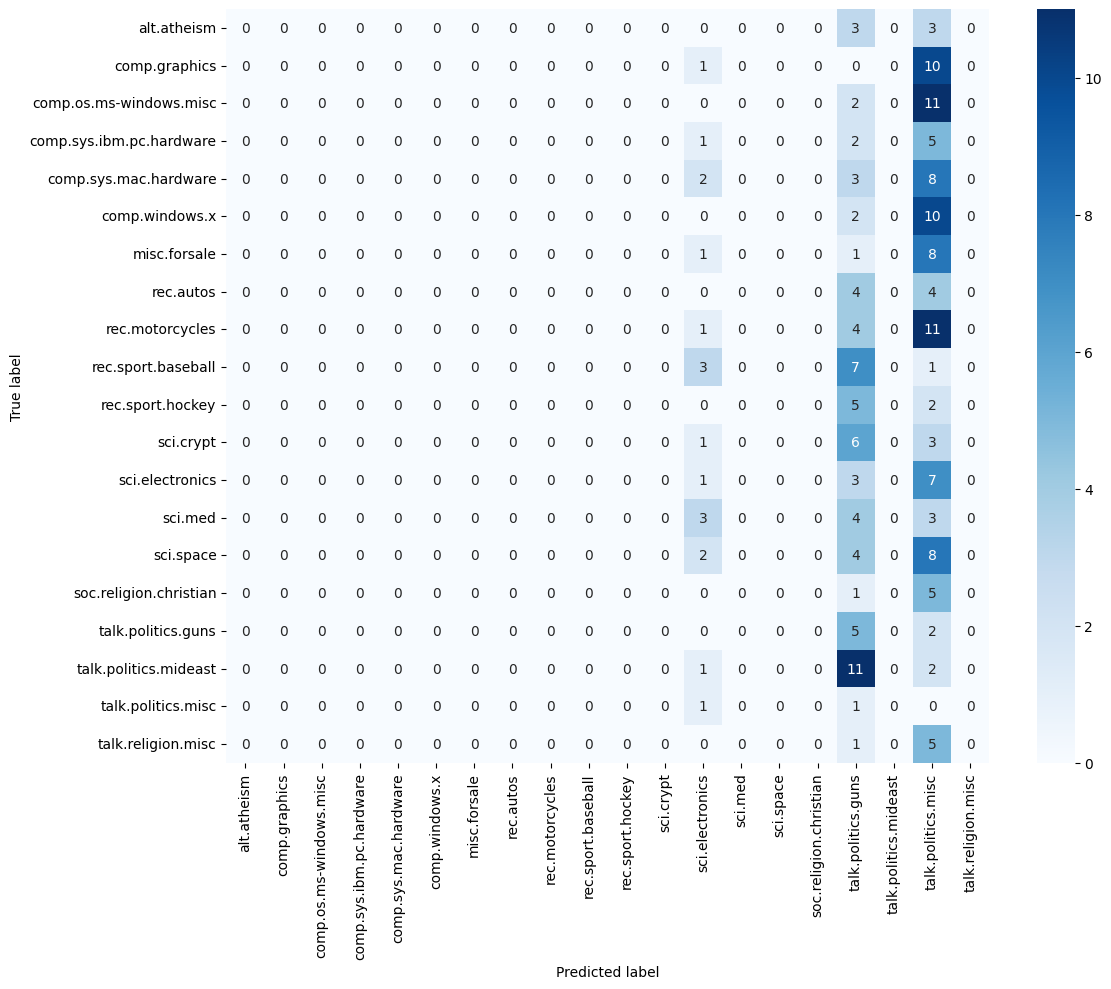

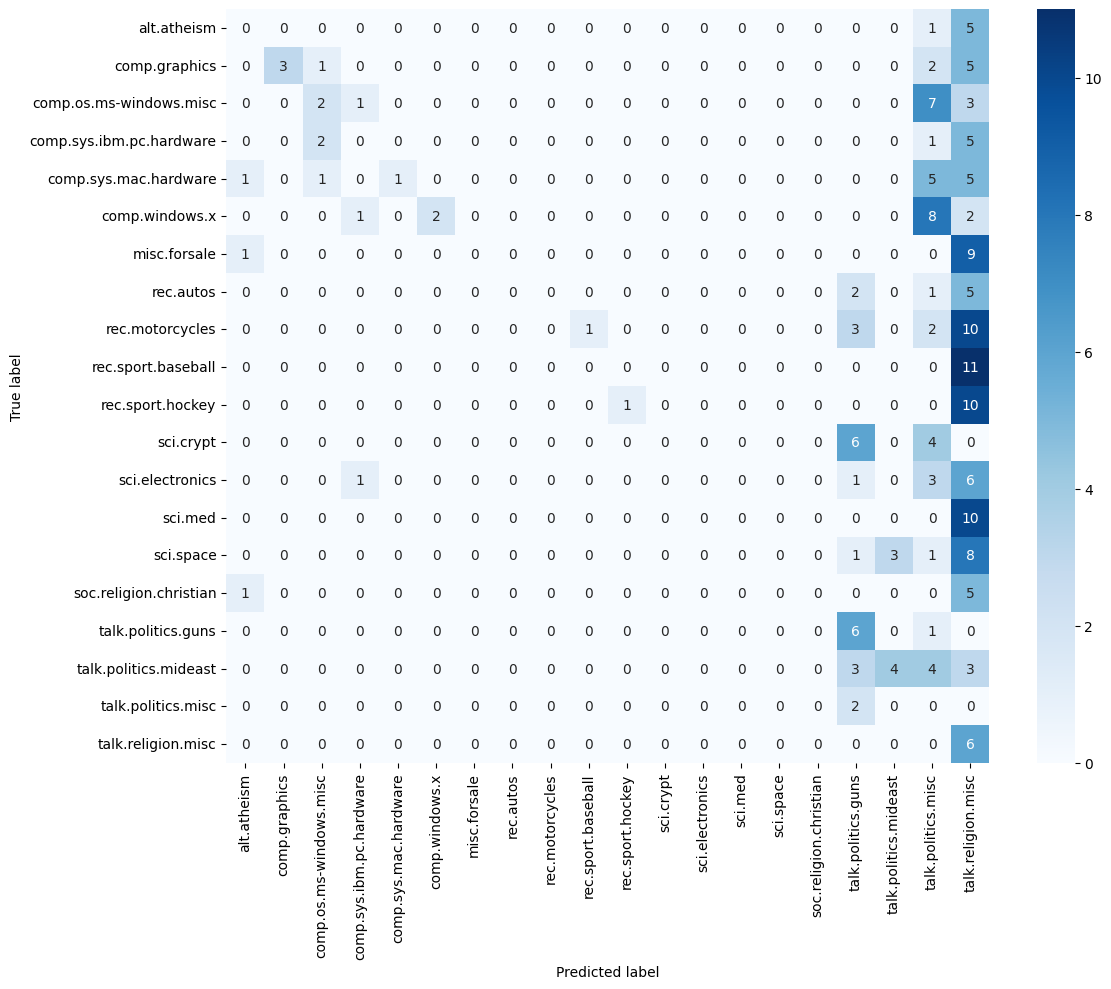

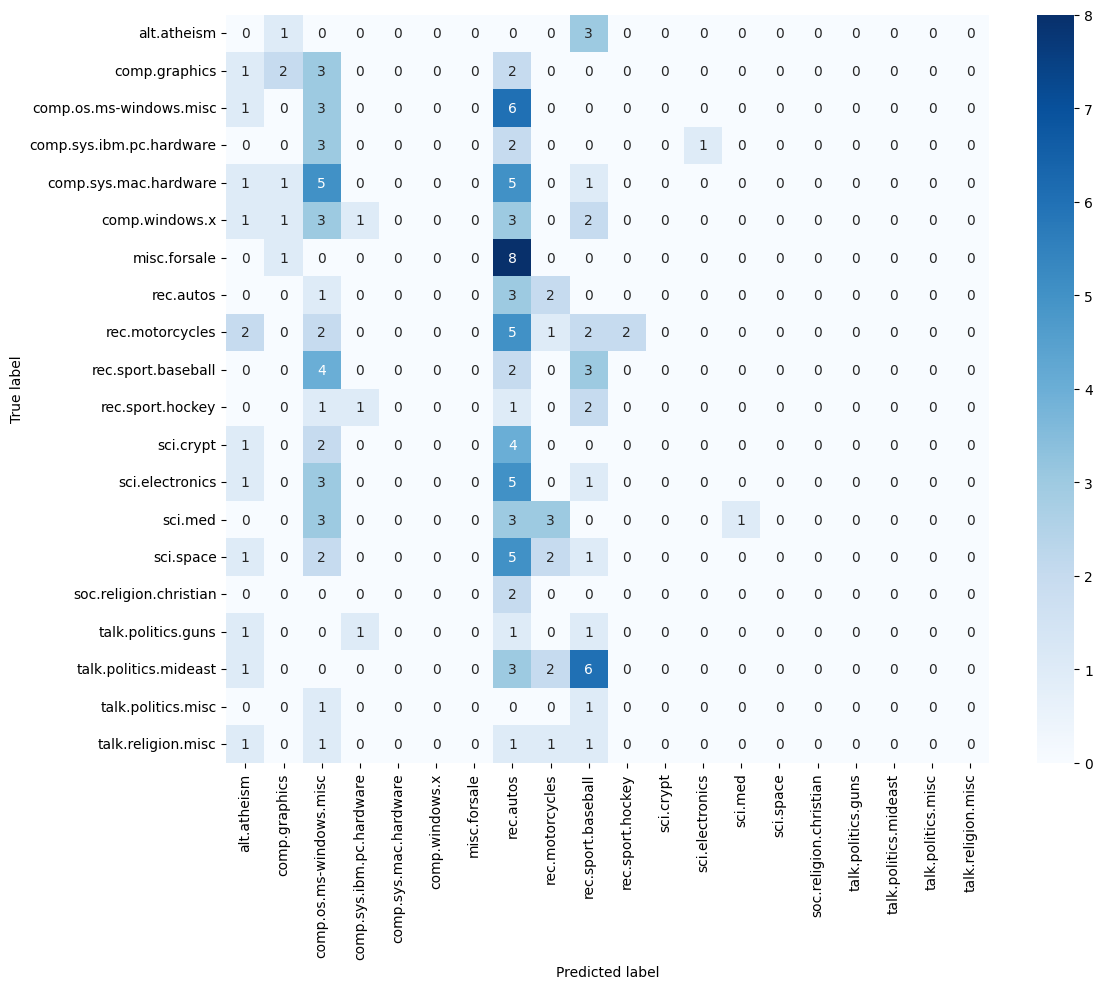

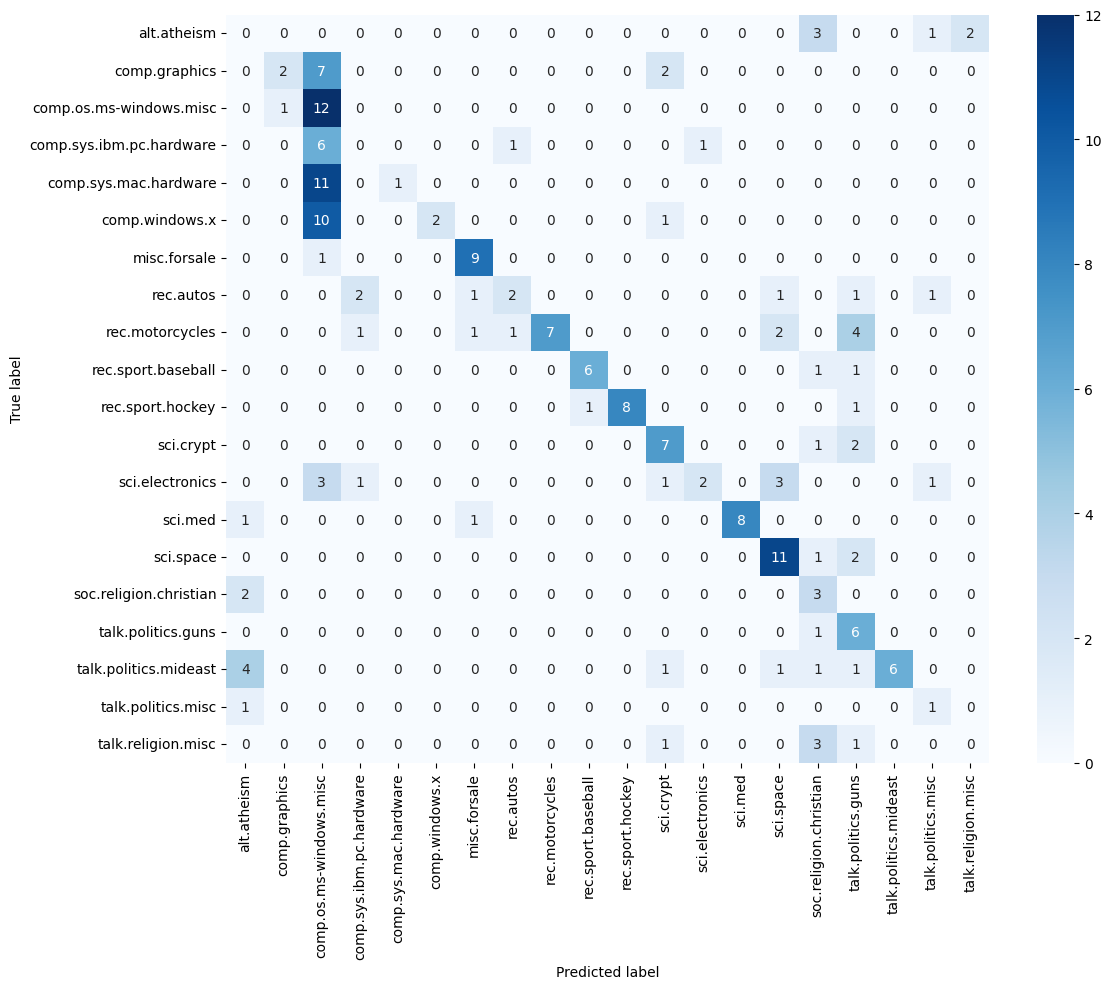

In [156]:
confusion_matrices = dict()

for model in models:
    confusion_matrices[model] = part1_1_cm(classification_data, model)
    part_1_1_vis(confusion_matrices[model])

★ Make sure the images are rendered in the notebook pdf you submit.

★ For each of the different classifiers, which pair of classes is most often confused?

★ Use the scratch space below to explore the documents that are misclassified most often with these class pairings, and include snippets of a few examples below.

★ Why might these pairs of classes be more difficult for the classifiers to distinguish?

In [157]:
# TODO: Use this scratch space to find documents
# that are examples of common misclassifications
col = "predictions_llama3.2:1b"
norm = classification_data[col].apply(normalize_prediction)
wrong = classification_data[
    (classification_data["newsgroup"] == "comp.windows.x") &
    (norm == "talk.politics.misc")
]

for _, r in wrong.iterrows():
    print(f"=== id {r['id']} | true: {r['newsgroup']} | pred: {r[col]} ===")
    print(r["text"])
    print("-" * 80 + "\n")
    break

print("=" * 80 + "\n")

col = "predictions_llama3.2"
norm = classification_data[col].apply(normalize_prediction)
wrong = classification_data[
    (classification_data["newsgroup"] == "rec.sport.baseball") &
    (norm == "talk.religion.misc")
]

for _, r in wrong.iterrows():
    print(f"=== id {r['id']} | true: {r['newsgroup']} | pred: {r[col]} ===")
    print(r["text"])
    print("-" * 80 + "\n")
    break

print("=" * 80 + "\n")

col = "predictions_gemma3:1b"
norm = classification_data[col].apply(normalize_prediction)
wrong = classification_data[
    (classification_data["newsgroup"] == "comp.sys.mac.hardware") &
    (norm == "rec.autos")
]

for _, r in wrong.iterrows():
    print(f"=== id {r['id']} | true: {r['newsgroup']} | pred: {r[col]} ===")
    print(r["text"])
    print("-" * 80 + "\n")
    break

print("=" * 80 + "\n")

col = "predictions_gemma3:4b"
norm = classification_data[col].apply(normalize_prediction)
wrong = classification_data[
    (classification_data["newsgroup"] == "comp.sys.mac.hardware") &
    (norm == "comp.os.ms-windows.misc")
]

for _, r in wrong.iterrows():
    print(f"=== id {r['id']} | true: {r['newsgroup']} | pred: {normalize_prediction(r[col])} ===")
    print(r["text"])
    print("-" * 80 + "\n")
    break

=== id 0 | true: comp.windows.x | pred: talk.politics.misc ===
From: tim@kimba.catt.citri.edu.au (Tim Liddelow)
Subject: Installing MIT X11R5 on Apollo
Organization: CATT Centre at CITRI, Melbourne, Australia
Lines: 14

Can any Apollo GURUS out there let me know of their experiences building MIT X11R5,
with or without GCC 2.3.3.  In particular, is there anything I should watch out for.

Thanks in advance

--tim 
________________________________________________________________________________
  Tim Liddelow                                          for(;;) fork();
  Systems Programmer
  Centre of Advanced Technology in Telecommunications   My brain on a bad day.
  CITRI, Melbourne, Australia                           
  internet : tim@kimba.catt.citri.edu.au                
  Phone : +61 3 282 2455   Fax : +61 3 282 2444	        
________________________________________________________________________________

------------------------------------------------------------------------------

1.
- Most confused pair for the first classifier: comp.windows.x getting predicted as talk.politics.misc
- Most confused pair for the second classifier: rec.sport.baseball getting predicted as talk.religion.misc
- Most confused pair for the third classifier: comp.sys.mac.hardware geting predicted as rec.autos
- Most confused pair for the fourth classifier: comp.sys.mac.hardware getting predicted as comp.os.ms-windows.misc

2.
- llama3.2:1b (id 0, comp.windows.x -> talk.politics.misc):
"Subject: Installing MIT X11R5 on Apollo ... experiences building MIT X11R5, with or
without GCC 2.3.3." 
- Clearly about the X Window System, no political content.

- llama3.2 (id 42, rec.sport.baseball -> talk.religion.misc):
"Re: MLB Standings and Scores ... it's not really a rabbitball year ... all but three
games had ten or more runs scored." 
- Clearly about baseball.

- gemma3:1b (id 55, comp.sys.mac.hardware -> rec.autos):
"My mac monitor displays about 20 vertical lines ... I replaced all the RAMs ... It's
a Mac IIcx." 
- Mac hardware troubleshooting, nothing about cars.

- gemma3:4b (comp.sys.mac.hardware -> comp.os.ms-windows.misc):
"Surely such an init would be very helpful to Powerbook owners who want to
do MIDI... I cannot imagine why it is not possible to do, unless it requires
Apple to divluge some secret. And if that is the case, the surely APPLE
could write the init. (Unless Apple brings out new models so fast these
days that even THEY don't know how they work)."
- About Apple, nothing about Windows

3.
The reason why these pairs of classes might be more difficult for the classifiers to distinguish is because the small models wants to guess or fall back on
broader sounding labels.
eg. For the three models (llama3.2:1b, llama3.2, gemma3:1b), the most confused pairs are between unrelated topics,
even though the documents contain clear topical keywords (X11R5, MLB scores, Mac IIcx).


### Part 1.2: Accuracy (5 points)
Complete the following function, then use it to compute and compare the accuracies of each classifier.

Model predictions are raw text, not clean labels. Pass each one through
`normalize_prediction` (defined in Part 1.0) before comparing it to the ground
truth, and do it consistently across Parts 1.1 through 1.5 -- comparing the raw
strings scores at least one of these models far below its real accuracy.

A prediction that is still not one of the labels after normalising counts as
incorrect in Parts 1.2 through 1.5. Part 1.1 is the exception: a confusion
matrix has no cell to put it in, so it is left out of the counts there.

★ Generate a table comparing the accuracy of each of the classifier systems.

★ Which one has the highest accuracy?

In [159]:
def part1_2_acc(x: DataFrame, y: str) -> float:
    # TODO: Implement this function
    correct = 0
    total = 0
    labels = x["newsgroup"]
    predicted = x[f"predictions_{y}"]
    for label,pred in zip(labels, predicted):
      total += 1
      pred = normalize_prediction(pred)
      if label == pred:
        correct += 1
    accuracy = correct / total
    return accuracy

accuracies: dict[str, float] = dict()

for model in models:
    accuracies[model] = part1_2_acc(classification_data, model)

save_results(accuracies, "results/accuracies.json")
print(accuracies)
best_model = max(accuracies, key=accuracies.get)
print(best_model) 
# TODO: Which model performed the best?

{'llama3.2:1b': 0.03, 'llama3.2': 0.125, 'gemma3:1b': 0.065, 'gemma3:4b': 0.465}
gemma3:4b


- gemma3:4b model is the best, it has the highest accuracy at 0.465, well ahead of llama3.2 (0.125),
gemma3:1b (0.065) and llama3.2:1b (0.030).

### Part 1.3: Precision (5 points)
Complete the following function that returns, for each class, the precision of the classifier's labels given ground-truth labels. (note: if there are no predictions for a given class, then precision should be 0)

★ Generate a table showing, for the best-performing classifier, the precision of its labels across each class.

★ For which class are its labels the most accurate? The least?

In [160]:
def part1_3_prec(x: DataFrame, y: str) -> dict[str, float]: #TP / (TP + FP)
    # TODO: Implement this function
    cm = part1_1_cm(x, y)
    classes = set(x["newsgroup"])
    precision = dict()
    for c in classes:
      true_positive = cm.get(c,{}).get(c,0)
      false_positive = 0
      for true_label, row in cm.items():
        if true_label != c:
          false_positive += row.get(c, 0)
      if true_positive + false_positive == 0:
        precision[c] = 0
      else:
        result = true_positive / (true_positive + false_positive)
        precision[c] = result
    return precision

if best_model not in models:
    print(f"best_model is still {best_model!r}. Set it in Part 1.2 to one of {models}, "
          f"then re-run this cell.")
    best_model_prec = None
else:
    best_model_prec = part1_3_prec(classification_data, best_model)

save_results(best_model_prec, "results/best_model_prec.json")

# TODO: Scratch space for analyzing the precision.
for c, p in sorted(best_model_prec.items(), key=lambda kv: kv[1]):
    print(f"{c:28s} {p:.2f}")


talk.religion.misc           0.00
comp.sys.ibm.pc.hardware     0.00
alt.atheism                  0.00
soc.religion.christian       0.21
comp.os.ms-windows.misc      0.24
talk.politics.misc           0.25
talk.politics.guns           0.32
rec.autos                    0.50
sci.crypt                    0.54
sci.space                    0.61
sci.electronics              0.67
comp.graphics                0.67
misc.forsale                 0.75
rec.sport.baseball           0.86
talk.politics.mideast        1.00
comp.sys.mac.hardware        1.00
rec.sport.hockey             1.00
rec.motorcycles              1.00
comp.windows.x               1.00
sci.med                      1.00


Three classes tie for the lowest precision at 0.00: talk.religion.misc,
comp.sys.ibm.pc.hardware and alt.atheism. Six tie for the highest at 1.00:
talk.politics.mideast, comp.windows.x, rec.sport.hockey, rec.motorcycles,
comp.sys.mac.hardware and sci.med.

Precision alone is misleading here, and pairing it with recall explains why.
comp.sys.mac.hardware has precision 1.00 but recall 0.08: gemma3:4b almost never
predicts that label and is right the few times it does. comp.os.ms-windows.misc
is the mirror image, precision 0.24 against recall 0.92, because it absorbs most
computing posts regardless of their true class. That is the catch-all behaviour
from the confusion matrix showing up as a low-precision, high-recall class.

### Part 1.4: Recall (5 points)
Complete the following function that returns, for each target class, the recall of the classifier's labels. (note: if there are no ground truth labels for a given class, the recall should be 0)

★ Generate a table showing, for each target class, the recall of the best-performing model's labels across each class.

★ For which class is recall the highest? The lowest?

In [161]:
def part1_4_rec(x: DataFrame, y: str) -> dict[str, float]: # TP / (TP+FN)
    # TODO: Implement this function
    cm = part1_1_cm(x, y)
    classes = set(x["newsgroup"])
    recall = dict()
    for c in classes:
      true_positive = cm.get(c,{}).get(c,0)
      total = (x["newsgroup"] == c).sum()
      recall[c] = true_positive/total
    return recall


if best_model not in models:
    print(f"best_model is still {best_model!r}. Set it in Part 1.2 to one of {models}, "
          f"then re-run this cell.")
    best_model_rec = None
else:
    best_model_rec = part1_4_rec(classification_data, best_model)

save_results(best_model_rec, "results/best_model_rec.json")

# TODO: Scratch space for analyzing the recall.
for c in sorted(best_model_rec, key=best_model_rec.get):
    print(f"{c:28s} rec {best_model_rec[c]:.2f}")


talk.religion.misc           rec 0.00
comp.sys.ibm.pc.hardware     rec 0.00
alt.atheism                  rec 0.00
comp.sys.mac.hardware        rec 0.08
comp.windows.x               rec 0.15
sci.electronics              rec 0.18
comp.graphics                rec 0.18
rec.autos                    rec 0.25
talk.politics.mideast        rec 0.43
rec.motorcycles              rec 0.44
soc.religion.christian       rec 0.50
talk.politics.misc           rec 0.50
rec.sport.baseball           rec 0.55
sci.crypt                    rec 0.70
rec.sport.hockey             rec 0.73
sci.space                    rec 0.79
sci.med                      rec 0.80
talk.politics.guns           rec 0.86
misc.forsale                 rec 0.90
comp.os.ms-windows.misc      rec 0.92


comp.os.ms-windows.misc has the highest recall at 0.92, with misc.forsale close
behind at 0.90. The lowest is a three-way tie at 0.00 (talk.religion.misc,
comp.sys.ibm.pc.hardware and alt.atheism), the same three classes with zero
precision, so gemma3:4b never got a single document in them right.

The classes absorbed into comp.os.ms-windows.misc show the cost: comp.sys.mac.hardware
(0.08), comp.windows.x (0.15) and comp.graphics (0.18) all have very low recall
because their documents were sent to the Windows label instead.

### Part 1.5: F1 (5 points)

A weighted average F1 score computes an average F1 score over all target classes, weighted by the true number of instances of that class:

![test](https://github.com/zinengtang/cs183-fall26-a1/blob/main/A1_Data/f1.png?raw=1)

Here, *f* is a classification function, *C* is the set of classes, *D* is the set of evaluation data with ground-truth labels, and *D_c* is the set of data whose ground-truth label is *c*.

Implement two functions below:
* A function that returns, for a target class, the F1 of a classifier's labels given ground truth labels
* A function that uses the previous function to compute a weighted average F1 score

In [162]:
def part1_5_class_f1(x: DataFrame, y: str, z: str) -> float: # F1 = 2 x ((P x R)/(P+R))
    # TODO: Implement this function
    # note: z is the class we want to compute F1 for, and y is the model name string
    p = part1_3_prec(x, y)[z]
    r = part1_4_rec(x, y)[z]
    if p + r == 0:
        return 0.0
    return float(2 * p * r / (p + r))

def part1_5_weighted_f1(x: DataFrame, y: str) -> float:
    # TODO: Implement this function
    total = 0.0
    for c in set(x["newsgroup"]):
      support = (x["newsgroup"] == c).sum()
      total += part1_5_class_f1(x, y, c) * support
    return float(total / len(x))

★ Generate a table comparing the weighted F1 score of each classifier.

★ Which is the best classifier according to weighted F1? How and why might this differ from an accuracy comparison (Part 1.2)?

In [163]:
f1s: dict[str, float] = dict()

for model in models:
    f1s[model] = part1_5_weighted_f1(classification_data, model)

save_results(f1s, "results/f1s.json")

# TODO: Scratch space for analyzing and reporting the F1.
for c in sorted(f1s, key=f1s.get, reverse=True):
    print(f"{c:28s} f1 {f1s[c]:.2f}")


gemma3:4b                    f1 0.46
llama3.2                     f1 0.12
gemma3:1b                    f1 0.05
llama3.2:1b                  f1 0.01


Ranked by weighted F1: gemma3:4b (0.46), llama3.2 (0.12), gemma3:1b (0.05),
llama3.2:1b (0.01). Same ranking as accuracy in Part 1.2 (0.465 / 0.125 / 0.065 /
0.030), and each model's F1 sits close to its accuracy.

They can differ because weighted recall is mathematically equal to accuracy -- the
per-class supports cancel, leaving total correct over total documents -- so precision
is the only possible source of difference. Accuracy asks whether each document was
labelled correctly; F1 also asks whether a label the model predicts is usually right.
A model that funnels documents into one or two catch-all labels is penalised by F1
but not by accuracy, since the sink label has poor precision and every class it
absorbs has poor recall.

The ranking does not change here because gemma3:4b leads on both. Its F1 (0.46) is
almost identical to its accuracy (0.465) despite over-using comp.os.ms-windows.misc,

## Part 2: Automatic speech recognition (25 points)
Here, we'll explore using a popular open-source automatic speech recognition system to compare its performance across English speakers whose native language differs.

### Part 2.0: Setup
`transcriptions.tsv` ships with the repo, so the cell below only downloads the Speech Accent Archive (https://www.kaggle.com/datasets/rtatman/speech-accent-archive/data) -- an 865MB archive that takes a while to extract -- when those transcripts are missing or incomplete.

In [164]:
import os
import pandas as pd

# transcriptions.tsv ships with the repo. The 865MB audio archive is only needed
# when it is missing or short, so decide that first and skip the download otherwise.
transcript_counts = {}
if os.path.exists('transcriptions.tsv'):
    with open('transcriptions.tsv') as infile:
        for line in infile:
            language, _, _ = line.rstrip("\n").partition("\t")
            transcript_counts[language] = transcript_counts.get(language, 0) + 1

need_to_transcribe = not transcript_counts or any(n != 20 for n in transcript_counts.values())

if need_to_transcribe:
    import kagglehub
    speech_accent_path = kagglehub.dataset_download("rtatman/speech-accent-archive")
    speakers = pd.read_csv(f"{speech_accent_path}/speakers_all.csv")
    language_counts = speakers['native_language'].value_counts()
    languages_with_over_20_samples = set(language_counts[language_counts >= 20].index)
else:
    languages_with_over_20_samples = set(transcript_counts)

print(f"{len(languages_with_over_20_samples)} languages with at least 20 samples:")
print(sorted(languages_with_over_20_samples))

21 languages with at least 20 samples:
['amharic', 'arabic', 'cantonese', 'dutch', 'english', 'farsi', 'french', 'german', 'italian', 'japanese', 'korean', 'macedonian', 'mandarin', 'polish', 'portuguese', 'romanian', 'russian', 'spanish', 'swedish', 'turkish', 'vietnamese']


If the transcripts do need regenerating, load WhisperX. This might take some time to load.

In [165]:
if need_to_transcribe:
    import whisperx

    # Needs whisperx >= 3.8: 3.4.2 could not load its own VAD against current
    # pyannote-audio, and it also caps out at Python 3.12, which Colab is past.
    whisperx_model = whisperx.load_model("tiny", "cpu", compute_type="float32", language="en")

Now let's run inference. This is the smallest model we could run inference on, so its performance isn't going to be great. But, it shouldn't take *too* long to run on your local machine!

In [166]:
from tqdm import tqdm

transcriptions = {language: list() for language in languages_with_over_20_samples}

if need_to_transcribe:
    recordings_filepath = f"{speech_accent_path}/recordings/recordings/"
    for language in languages_with_over_20_samples:
        print(f"Transcribing for native language {language}...")
        for i in tqdm(range(20)):
            filename = f"{language}{i + 1}.mp3"
            audio = whisperx.load_audio(f"{recordings_filepath}/{filename}")
            transcription = whisperx_model.transcribe(audio, language="en")
            # flatten to text here, so this path and the tsv path agree on the type
            text = " ".join(segment["text"] for segment in transcription["segments"])
            transcriptions[language].append(" ".join(text.split()))

    with open("transcriptions.tsv", "w") as ofile:
        for language, transcripts in transcriptions.items():
            for transcript in transcripts:
                ofile.write(f"{language}\t{transcript}\n")
else:
    with open('transcriptions.tsv') as infile:
        for line in infile:
            # partition rather than split so an empty transcript is still a valid row
            language, _, transcript = line.rstrip("\n").partition("\t")
            if language in transcriptions:
                transcriptions[language].append(transcript)

### Part 2.1: Word error rate (10 points)
Implement the following function to compute the word error rate of a candidate transcription against a reference. It takes the **reference** first and the candidate second, matching the call below. Each of the recordings we transcribed are readings of the same English text: *"Please call Stella.  Ask her to bring these things with her from the store:  Six spoons of fresh snow peas, five thick slabs of blue cheese, and maybe a snack for her brother Bob.  We also need a small plastic snake and a big toy frog for the kids.  She can scoop these things into three red bags, and we will go meet her Wednesday at the train station."*

Compare the two token lists case-insensitively. Whether a transcript writes
*Please* or *please* is a choice the ASR system made about how to render the
words it heard, not a recognition error, so folding case keeps the metric
measuring what it is supposed to measure.

In [167]:
def part2_1(x: list[str], y: list[str]) -> float:
    # TODO: Implement this function.
    # note: x is the tokenised reference and y is the tokenised candidate.
    # The word error rate is normalised by the length of the reference, so
    # getting these the wrong way round gives a plausible-looking wrong answer.

    # the reference is already tokenised
    ref = [a.lower() for a in x]
    candidate = [b.lower() for b in y]

    grid = []
    for row in range(len(ref)+1):
      grid.append([0] * (len(candidate) + 1))

    #base cases
    for i in range(len(ref)+1):
      grid[i][0] = i
    for j in range(len(candidate)+1):
      grid[0][j] = j

    for i in range(1, len(ref)+1):
      for j in range(1, len(candidate)+1):
          if ref[i-1] == candidate[j-1]:
            grid[i][j] = grid[i-1][j-1]
          else:
            grid[i][j] = 1 + min(grid[i-1][j-1], grid[i][j-1], grid[i-1][j])
    return grid[len(ref)][len(candidate)] / len(ref) #rate


Then let's evaluate for all of the candidate transcriptions and each of the native languages.

★ Generate a table comparing the average WER across each of the languages.

In [168]:
import nltk
nltk.download('punkt_tab')

reference = "Please call Stella.  Ask her to bring these things with her from the store: " \
            "Six spoons of fresh snow peas, five thick slabs of blue cheese, and maybe a snack " \
            "for her brother Bob.  We also need a small plastic snake and a big toy frog for the kids. " \
            "She can scoop these things into three red bags, and we will go meet her Wednesday at the "\
            "train station."

language_wers = {language: list() for language in languages_with_over_20_samples}
for language, transcripts in transcriptions.items():
    for candidate in transcripts:
        language_wers[language].append(part2_1(nltk.word_tokenize(reference), nltk.word_tokenize(candidate)))

save_results(language_wers, "results/language_wers.json")

# TODO: Scratch space for computing average WER and generating a table to compare across native languages.
import pandas as pd

table = pd.DataFrame([
    {"language": lang, "avg_wer": sum(wers) / len(wers), "n": len(wers)}
    for lang, wers in language_wers.items()
]).sort_values("avg_wer")

print(table.to_string(index=False))

  language  avg_wer  n
    german 0.083766 20
   english 0.085714 20
macedonian 0.092857 20
   swedish 0.101299 20
  romanian 0.109091 20
     dutch 0.114286 20
     farsi 0.114286 20
    polish 0.131169 20
  japanese 0.133117 20
    french 0.140260 20
    arabic 0.141558 20
   italian 0.151948 20
portuguese 0.160390 20
   russian 0.161039 20
  mandarin 0.166883 20
    korean 0.172727 20
 cantonese 0.175325 20
   turkish 0.186364 20
   spanish 0.221429 20
   amharic 0.227273 20
vietnamese 0.266234 20


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/yvonne/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### Part 2.2: Confidence intervals (10 points)

Each average WER you just computed comes from 20 recordings. Twenty *different*
speakers of the same native language would have given you a different average.
Before ranking the languages, you need to know how much that number moves.

You cannot collect more recordings, but you can estimate the spread from the
sample you already have. Draw 20 values *with replacement* from a language's 20
WERs and average them; that is one plausible alternative sample. Repeat it many
times and the middle 95% of those averages is a 95% confidence interval for the
mean.

Implement the function below. `x` is the list of WER values for one language and
`y` is how many times to resample; return the lower and upper bounds of the 95%
interval.

In [169]:
import random
def part2_2_ci(x: list[float], y: int = 10000) -> tuple[float, float]:
    # TODO: Implement this function.
    l = []
    for i in range(y):
        draw = random.choices(x, k=len(x))
        avg = sum(draw) / len(draw)
        l.append(avg)
    # since confidence interval is 95%, 100 - 95 = 5
    l.sort()
    list_start = int(y * (0.025))
    chopped_list = l[list_start: y-list_start]
    return (chopped_list[0], chopped_list[-1])



language_wer_cis = dict()
for language, wers in language_wers.items():
    language_wer_cis[language] = part2_2_ci(wers)

save_results(language_wer_cis, "results/language_wer_cis.json")

# TODO: Scratch space for adding the intervals to your Part 2.1 table.
import pandas as pd

table = pd.DataFrame([
    {"language": lang, "avg_wer": sum(wers) / len(wers), "n": len(wers), "lower_interval": language_wer_cis[lang][0], "higher_interval": language_wer_cis[lang][1]}
    for lang, wers in language_wers.items()
]).sort_values("avg_wer")

print(table.to_string(index=False))


  language  avg_wer  n  lower_interval  higher_interval
    german 0.083766 20        0.067532         0.101299
   english 0.085714 20        0.063636         0.112338
macedonian 0.092857 20        0.072727         0.116883
   swedish 0.101299 20        0.075974         0.135065
  romanian 0.109091 20        0.088961         0.131818
     dutch 0.114286 20        0.091558         0.137662
     farsi 0.114286 20        0.086364         0.148701
    polish 0.131169 20        0.096753         0.168182
  japanese 0.133117 20        0.101948         0.165584
    french 0.140260 20        0.107792         0.172727
    arabic 0.141558 20        0.118182         0.168182
   italian 0.151948 20        0.119481         0.189610
portuguese 0.160390 20        0.103896         0.236364
   russian 0.161039 20        0.120779         0.205195
  mandarin 0.166883 20        0.134416         0.201948
    korean 0.172727 20        0.130519         0.218182
 cantonese 0.175325 20        0.129870         0

★ Extend your table from Part 2.1 with each language's confidence interval.

★ You named the lowest-WER languages in Part 2.1. Taking the intervals into
account, which of those are actually distinguishable from one another, and which
are not?

★ Some pairs of languages *are* clearly separated. What is different about those
pairs, compared to the ones you cannot separate?

★ What would you need in order to separate the languages whose intervals
currently overlap?

- Not distinguishable: the four lowest-WER languages overlap heavily. German
  [0.068, 0.101], English [0.064, 0.112], Macedonian [0.073, 0.117] and Swedish
  [0.076, 0.135] sit almost on top of one another, so the ordering among them is not
  supported by the data. Native English speakers are not distinguishable from German
  or Macedonian, so speaking the target language natively buys no measurable advantage.

- Clearly separated: Vietnamese [0.199, 0.340], Amharic [0.175, 0.284] and Spanish
  [0.169, 0.282] sit entirely clear of that group.

- What differs about the separable pairs: the distance between their means is large
  relative to the width of their intervals. They are far apart in the ranking rather
  than adjacent, and adjacent languages differ by less than the sampling noise in a
  20-speaker average. Interval width varies too, for eg. Romanian [0.089, 0.132] is tight
  because its speakers were consistent, while Portuguese [0.104, 0.236] is wide,
  which makes Portuguese hard to separate from anything.

- To separate the overlapping languages: more recordings per language. Interval width
  shrinks roughly as 1/sqrt(n), so halving it means going from 20 speakers to about 80.
  Reducing within-language variance would also help, controlling for recording
  quality, years of English exposure and age of acquisition, which the Speech Accent
  Archive leaves uncontrolled.

### Part 2.3: Error analysis (5 points)
★ Which languages have the lowest WER? Which have the highest?

★ Why might these languages have lower WER?

★ Which of the differences you just described survive the confidence intervals
from Part 2.2, and which are within the noise?

- Lowest WER: German (0.084), English (0.086), Macedonian (0.093), Swedish (0.101).
  Highest: Vietnamese (0.266), Amharic (0.227), Spanish (0.221).

- Why the low-WER languages might do better: Whisper's training data is dominated by
  English and widely-spoken European languages, so accents phonologically close to the
  English it saw most of are better covered. German and Swedish are Germanic languages
  sharing much of English's consonant and vowel inventory. The high-WER languages differ
  more sharply. Vietnamese is tonal with heavy syllable-final consonant reduction, and
  Spanish has a five-vowel system that collapses several English vowel contrasts.

- Which differences survive the intervals: the gap between the top group
  (German/English/Macedonian/Swedish) and the bottom group (Vietnamese/Amharic/Spanish)
  survives, the intervals do not overlap and the error rate is two to three times
  higher. The ordering within each group does not. German vs English vs Macedonian is
  entirely within the noise, as is Spanish vs Amharic. 

## Part 3: Machine translation (25 points)
In this part we will evaluate models on their abilities to translate text via BLEU score.

### Part 3.0: Setup


Prepare the dataset we will use for evaluation. These are the Czech, Chinese and Gujarati halves of the standard WMT19 into-English translation sets. We will just use the first 25 examples of each for evaluation.

In [170]:
from datasets import load_dataset
from itertools import islice

# streaming=True reads only the validation shards. Without it, load_dataset also
# materialises every training split -- 7.3M cs-en rows, 26M zh-en rows, ~13GB of
# HuggingFace cache -- to reach the 75 sentences we actually evaluate on.
hf_dataset_cs = load_dataset("wmt/wmt19", "cs-en", split="validation", streaming=True)
hf_dataset_zh = load_dataset("wmt/wmt19", "zh-en", split="validation", streaming=True)
hf_dataset_gu = load_dataset("wmt/wmt19", "gu-en", split="validation", streaming=True)

dataset_items_cs = []
for i, item in enumerate(islice(hf_dataset_cs, 25)):
    dataset_items_cs.append({
        'id': i,
        'czech_text': item['translation']['cs'],
        'english_text': item['translation']['en']
    })

dataset_items_zh = []
for i, item in enumerate(islice(hf_dataset_zh, 25)):
    dataset_items_zh.append({
        'id': i,
        'chinese_text': item['translation']['zh'],
        'english_text': item['translation']['en']
    })

dataset_items_gu = []
for i, item in enumerate(islice(hf_dataset_gu, 25)):
    dataset_items_gu.append({
        'id': i,
        'gujarati_text': item['translation']['gu'],
        'english_text': item['translation']['en']
    })

dataset_cs = pd.DataFrame(dataset_items_cs)
dataset_zh = pd.DataFrame(dataset_items_zh)
dataset_gu = pd.DataFrame(dataset_items_gu)
print(f"Loaded translation data of shape {dataset_cs.shape} with columns {dataset_cs.columns.tolist()}.")

Loaded translation data of shape (25, 3) with columns ['id', 'czech_text', 'english_text'].


We will use a simple nltk based tokenizer to encode the n-gram tokens for computing the bleu score.

In [171]:
import nltk
from nltk.tokenize import word_tokenize

def tokenize_text(text):
    # Download required NLTK data if not already downloaded
    try:
        nltk.data.find('tokenizers/punkt_tab')
    except LookupError:
        nltk.download('punkt_tab')

    # Tokenize the text into a list of tokens
    tokens = word_tokenize(text)
    return tokens


In [172]:
tokenize_text("Welcome to CS-183: we are learning about NLP evaluations today!!!")

['Welcome',
 'to',
 'CS-183',
 ':',
 'we',
 'are',
 'learning',
 'about',
 'NLP',
 'evaluations',
 'today',
 '!',
 '!',
 '!']

In [173]:
dataset_cs.head()

,id,czech_text,english_text
0,0,Hnutí za občanská práva vydalo cestovní výstra...,Civil rights group issues travel warning for M...
1,1,Národní asociace pro zvýhodňování barevných li...,The National Association for the Advancement o...
2,2,"„Cestovní doporučení NAACP pro stát Missouri, ...","""The NAACP Travel Advisory for the state of Mi..."
3,3,"NAACP uvedlo, že k tomuto kroku přistoupilo na...",A recent Missouri law making it harder for peo...
4,4,„Dochází k porušování občanských práv.,"""You have violations of civil rights that are ..."


In [174]:
dataset_zh.head()

,id,chinese_text,english_text
0,0,上周，古装剧《美人私房菜》临时停播，意外引发了关于国产剧收视率造假的热烈讨论。,"Last week, the broadcast of period drama “Beau..."
1,1,民权团体针对密苏里州发出旅行警告,Civil rights group issues travel warning for M...
2,2,由于密苏里州的歧视性政策和种族主义袭击，美国有色人种促进协会 (NAACP) 向准备前往密苏...,The National Association for the Advancement o...
3,3,“2017 年 8 月 28 日生效的 NAACP 密苏里州旅行咨询中呼吁，因近期密苏里州发...,"""The NAACP Travel Advisory for the state of Mi..."
4,4,NAACP 指出，最近通过的一项密苏里州法律使得人们更难赢得歧视诉讼，该州执法也一定程度上针...,A recent Missouri law making it harder for peo...


In [175]:
dataset_gu.head()

,id,gujarati_text,english_text
0,0,બેરિયર ભાંગી ગયા પછી સેન્ટ્રલ પાર્કમાં હજારો ગ...,Thousands in Central Park panic after barrier ...
1,1,એક રાજકીય કાર્યક્રમમાં પોલીસ બેરીયરના ભંગાણને ...,The collapse of a police barrier sent thousand...
2,2,ડેમોક્રેટિક ન્યૂયોર્ક સરકારની મોટી નામી હસ્તીઓ...,Big-name personalities from Democratic New Yor...
3,3,શનિવારે સાંજે બેરીયર પડ્યા પછી અધિકારીઓએ ટોળાન...,Authorities quickly assured the crowd they wer...
4,4,સામાજિક ન્યાયના સળગતા મુદ્દાઓએ તડકાની ખરા બપોર...,Burning social justice issues dominated the ev...


now let's get the model predictions for these translations

In [176]:
def get_translation_prompt(text, source_language):
	translation_prompt = f"Translate the following text from {source_language} to English. Output only the translation, no other text."
	translation_prompt += f"\n\nText:\n{text}"
	return translation_prompt

prompts_cs = [get_translation_prompt(text, "Czech") for text in dataset_cs["czech_text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_translation_data_cs", prompts_cs)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=512)
	cache_inferences(model, "pt3_1_translation_data_cs", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_translation_data_cs", prompts_cs)
	dataset_cs[f"predictions_{model}"] = inferences

prompts_zh = [get_translation_prompt(text, "Chinese") for text in dataset_zh["chinese_text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_translation_data_zh", prompts_zh)
	print(f"Remaining prompts: {len(remaining_prompts)}")
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=512)
	cache_inferences(model, "pt3_1_translation_data_zh", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_translation_data_zh", prompts_zh)
	dataset_zh[f"predictions_{model}"] = inferences

prompts_gu = [get_translation_prompt(text, "Gujarati") for text in dataset_gu["gujarati_text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_translation_data_gu", prompts_gu)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=512)
	cache_inferences(model, "pt3_1_translation_data_gu", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_translation_data_gu", prompts_gu)
	dataset_gu[f"predictions_{model}"] = inferences

Running inference for llama3.2:1b


0it [00:00, ?it/s]


Running inference for llama3.2


0it [00:00, ?it/s]


Running inference for gemma3:1b


...

0it [00:00, ?it/s]


Running inference for gemma3:1b


0it [00:00, ?it/s]


Running inference for gemma3:4b


0it [00:00, ?it/s]


In [177]:
dataset_cs

,id,czech_text,english_text,predictions_llama3.2:1b,predictions_llama3.2,predictions_gemma3:1b,predictions_gemma3:4b
0,0,Hnutí za občanská práva vydalo cestovní výstra...,Civil rights group issues travel warning for M...,Travel warning issued by the rights movement f...,Movement for Civil Rights issued a travel warn...,Committee for Civic Rights issued a travel war...,The Civil Rights Movement issued a travel warn...
1,1,Národní asociace pro zvýhodňování barevných li...,The National Association for the Advancement o...,National Association for the Advancement of Co...,National Association for the Advancement of Co...,The National Association for the Advancement o...,The National Association for the Advancement o...
2,2,"„Cestovní doporučení NAACP pro stát Missouri, ...","""The NAACP Travel Advisory for the state of Mi...",Travel advisories of the NAACP for the state o...,The NAACP travel advisory for the state of Mis...,“NAACP travel recommendation for the state of ...,“Travel recommendations from the NAACP for the...
3,3,"NAACP uvedlo, že k tomuto kroku přistoupilo na...",A recent Missouri law making it harder for peo...,They have taken this step based on the current...,The NAACP stated that it took this step based ...,The NAACP has stated that this step was taken ...,NAACP stated that it took this step based on t...
4,4,„Dochází k porušování občanských práv.,"""You have violations of civil rights that are ...","""Something is being destroyed.""",There is a violation of civil rights.,“He is violating citizens’ rights.”,Human rights are being violated.
5,5,Lidé jsou zastavováni policisty jen kvůli barv...,They're being pulled over because of their ski...,They are stopped by police just because of the...,People are stopped by police just because of t...,People are stopped by police only because of t...,“People are being stopped by police solely bec...
6,6,„Hromadí se nám dosud největší množství stížno...,"""We are hearing complaints at a rate we haven'...","""Despite our complaints, we still have the lar...",The complaints are mounting to the greatest ex...,“We have received the largest amount of compla...,“We are still accumulating the largest amount ...
7,7,"Jedná se o první varování svého druhu, které o...",It is the first such warning that the organiza...,"It is the first warning of its species, which ...",It is the first warning of its kind that the o...,"It is the first warning of its species, issued...",This is the first of its kind warning issued b...
8,8,"Mezi incidenty, které organizace citovala, byl...",The group cited incidents such as racial slurs...,racially motivated hate speech incidents cited...,"Among the incidents cited by the organization,...","During incidents cited by the organization, ra...",Among the incidents cited by the organizations...
9,9,Sanders zemřel za sporných okolností na začátk...,Sanders died under questionable circumstances ...,He died under suspicious circumstances at the ...,He died under disputed circumstances at the be...,Sanders died of suspicious circumstances at th...,Sanders died under disputed circumstances at t...


In [178]:
dataset_zh

,id,chinese_text,english_text,predictions_llama3.2:1b,predictions_llama3.2,predictions_gemma3:1b,predictions_gemma3:4b
0,0,上周，古装剧《美人私房菜》临时停播，意外引发了关于国产剧收视率造假的热烈讨论。,"Last week, the broadcast of period drama “Beau...","Last week, the period drama ""Beautiful Private...","Last week, the costume drama ""Beauty and the F...","Last week, the temporary suspension of the his...","Last week, the costume drama ""Beauty's Private..."
1,1,民权团体针对密苏里州发出旅行警告,Civil rights group issues travel warning for M...,Travel warnings issued by civil rights groups ...,Human rights groups issue travel warning for M...,Civil rights groups are issuing travel warning...,Civil rights groups have issued travel warning...
2,2,由于密苏里州的歧视性政策和种族主义袭击，美国有色人种促进协会 (NAACP) 向准备前往密苏...,The National Association for the Advancement o...,Due to the state's discriminatory policies and...,Due to discriminatory policies and racist atta...,Due to discriminatory policies and racial atta...,Due to discriminatory policies and racial atta...
3,3,“2017 年 8 月 28 日生效的 NAACP 密苏里州旅行咨询中呼吁，因近期密苏里州发...,"""The NAACP Travel Advisory for the state of Mi...","""NAACP urges all non-white US citizens, touris...","The NAACP Travel Advisory for Missouri, effect...","“On August 28, 2017, the NAACP has issued a ca...","Issued on August 28, 2017, the NAACP’s Missour..."
4,4,NAACP 指出，最近通过的一项密苏里州法律使得人们更难赢得歧视诉讼，该州执法也一定程度上针...,A recent Missouri law making it harder for peo...,The NAACP has stated that a recent Missouri la...,The NAACP stated that a recent law passed in M...,The NAACP has pointed out that a recent law in...,The NAACP pointed out that a recently passed M...
5,5,侵犯公民权利的行为正发生在人们身上。,"""You have violations of civil rights that are ...",Violations of citizen rights are happening all...,The behavior that infringes on citizens' right...,Violations of human rights are happening right...,Actions violating citizens' rights are current...
6,6,他们因肤色被停车盘问，被殴打或被杀害，”密苏里州 NAACP 主席罗德·查培尔告诉堪萨斯城星...,They're being pulled over because of their ski...,They were stopped and beaten or killed by driv...,They were beaten or killed because of their sk...,“They were questioned about their skin color a...,“They were stopped and questioned because of t...
7,7,“我们收到了许多投诉，数量前所未有。”,"""We are hearing complaints at a rate we haven'...","""We have received many complaints, the number ...","We have received many complaints, a number unp...","We have received many complaints, the number i...","We have received a large number of complaints,..."
8,8,这是该组织在美国针对某个州发布的第一个此类警告。,It is the first such warning that the organiza...,This is the first warning issued by the organi...,This is the first of its kind warning issued b...,This is the first such warning issued by this ...,This is the first such warning issued by the o...
9,9,该组织援引了密苏里大学对黑人学生的种族诽谤以及 28 岁田纳西州黑人男性托利·桑德斯的死亡事件。,The group cited incidents such as racial slurs...,The organization cited the racist remarks agai...,The organization cited the racial slurs direct...,The organization invoked the assistance of Mid...,This organization cited the Missouri Universit...


In [179]:
dataset_gu

,id,gujarati_text,english_text,predictions_llama3.2:1b,predictions_llama3.2,predictions_gemma3:1b,predictions_gemma3:4b
0,0,બેરિયર ભાંગી ગયા પછી સેન્ટ્રલ પાર્કમાં હજારો ગ...,Thousands in Central Park panic after barrier ...,"After being beaten, he ran into a hundred thou...","After the Beriyar was broken, hundreds of peop...",The potatoes collapsed and thousands of people...,"After the barrier collapsed, thousands panicke..."
1,1,એક રાજકીય કાર્યક્રમમાં પોલીસ બેરીયરના ભંગાણને ...,The collapse of a police barrier sent thousand...,Thousands of people were trapped in fear of be...,Thousands of people were forced to take shelte...,“A traffic accident caused by the breakdown of...,Thousands of people were put in difficulty due...
2,2,ડેમોક્રેટિક ન્યૂયોર્ક સરકારની મોટી નામી હસ્તીઓ...,Big-name personalities from Democratic New Yor...,The Democratic New York State Legislature has ...,Democratic New York government's prominent fig...,Democratic New York government’s large petitio...,Democratic New York state dignitaries Andrew C...
3,3,શનિવારે સાંજે બેરીયર પડ્યા પછી અધિકારીઓએ ટોળાન...,Authorities quickly assured the crowd they wer...,The officials assured the locals that the poli...,After the Beriyar (a type of fruit) fell on Sa...,"On Saturday evening, after encountering obstac...",After the barrier was erected on Saturday even...
4,4,સામાજિક ન્યાયના સળગતા મુદ્દાઓએ તડકાની ખરા બપોર...,Burning social justice issues dominated the ev...,Social justice movements have started to take ...,The phenomenon of social justice issues escala...,"Social justice issues have ignited a spark, le...",The burning issues of social justice overshado...
5,5,"લગભગ 60,000 લોકોથી ગ્લોબલ સિટીઝન ફેસ્ટિવલ માટે...","About 60,000 people filled the park's Great La...",The main gate of the global city festival has ...,"The park became almost 60,000 people for the G...","Approximately 60,000 people gathered at the pa...",The Great Lawn of the park was packed with alm...
6,6,કેટલાક સ્પીકરોએ પ્રેક્ષકોને સુપ્રીમ કોર્ટના નો...,Some speakers asked the audience to call their...,Some members of the Spikors have said that the...,Some speakers called upon their Congress party...,Some politicians asked their congress members ...,Some speakers asked their congressional member...
7,7,"બીજી ઓક્ટોબરથી અન્ના હજારે કરશે ભૂખ હડતાળ, PM ...",Anna Hazare will go on hunger strike from 2nd ...,He will write a letter to PM Modi from Annha.,"From October, Anna Hazare will start hunger st...","Second October to half-way until the next day,...",Anna Hazare will go on a hunger strike from Oc...
8,8,મહારાષ્ટ્ર: સામાજીક કાર્યકર્તા અન્ના હજારેએ બી...,Maharashtra: The social activist Anna Hazare h...,The social worker Annapoorna Hazare has filed ...,Maharashtra: Social activist Anna Hajar has an...,Maharashtra: The Social Workers Ananya have be...,Maharashtra: Social worker Anna Hazare has ann...
9,9,અન્ના હજારેએ વડાપ્રધાન પર પ્રહાર કરતા કહ્યું ક...,Anna Hazare has heavily criticized the Prime m...,Annaji has said that the government led by the...,Anna Hazare has said that the BJP-led governme...,"At times, the Prime Minister was threatened wi...","Anna Hazare attacked the Prime Minister, sayin..."


### Part 3.1 n-gram precision (5 points)

complete the following function to calculate the n-gram precision of a predicted translation given the reference.

`pred` and `ref` are the raw translation strings, the same ones `bleu` is given in Part 3.3. Use the `tokenize_text` helper from Part 3.0 on them.

In [180]:

def ng_prec(pred, ref, n):
    # TODO: Implement this function.
    pred_list = tokenize_text(pred)
    ref_list = tokenize_text(ref)

    ref_ngrams= []
    pred_ngrams = []

    for i in range(len(ref_list) - n + 1):
      ref_ngrams.append(tuple(ref_list[i:i+n]))
    for i in range(len(pred_list) - n + 1):
      pred_ngrams.append(tuple(pred_list[i:i+n]))

    from collections import Counter
    pred_counts = Counter(pred_ngrams) # unique
    ref_counts = Counter(ref_ngrams)

    match_count = 0
    for pred_ngram, pred_count in pred_counts.items():
      for ref_ngram, ref_count in ref_counts.items():
        if pred_ngram == ref_ngram:
          match_count += min(pred_count, ref_count)
    if len(pred_ngrams) == 0:
      return 0
    return match_count / len(pred_ngrams)

In [181]:
ngram_precisions_cs = dict()
for model in models:
    ngram_precisions_cs[model] = [
        [ng_prec(prediction, reference, n) for n in (1, 2, 3, 4)]
        for prediction, reference in zip(dataset_cs[f"predictions_{model}"], dataset_cs["english_text"])
    ]

save_results(ngram_precisions_cs, "results/ngram_precisions_cs.json")

### Part 3.2 brevity penalty (5 points)

complete the following function to calculate the brevity penalty for the bleu score

`pred` and `ref` are the raw strings here too.

In [182]:
import math

def brev_pen(pred, ref):
    # TODO: Implement this function.
    pred_list = tokenize_text(pred)
    ref_list = tokenize_text(ref)

    p = len(pred_list)
    r = len(ref_list)
    bp = 0
    if p == 0:
      return 0.0
    if p > r:
      bp = 1
    else:
      bp = math.exp(1-r/p)
    return bp



In [183]:
brevity_penalties_cs = dict()
for model in models:
    brevity_penalties_cs[model] = [
        brev_pen(prediction, reference)
        for prediction, reference in zip(dataset_cs[f"predictions_{model}"], dataset_cs["english_text"])
    ]

save_results(brevity_penalties_cs, "results/brevity_penalties_cs.json")

### Part 3.3 putting it together (10 points)

complete the following function to calculate the full bleu score, using the two functions from the previous parts. Represent the bleu score as discussed in class, using the 1, 2, 3, and 4 gram precisions.

Sentence-level BLEU over 25 short sentences hits zero 4-gram precision often —
for some model and language pairs, on most of the sentences. Taken literally the
geometric mean then makes the whole score exactly 0, and half your table ties at
0.0 with no way to tell the bad translations from the hopeless ones. Substitute a
small constant (use `1e-7`) for any n-gram precision that comes out 0, so the
scores stay comparable.

In [184]:
def bleu(pred, ref):
    # TODO: Implement this function.

    # BLEU = BP × exp( Σₙ₌₁ᴺ wₙ · log pₙ )
    N = 4
    w = 1 / N
    total = 0.0
    for n in range(1, N + 1):
        p = ng_prec(pred, ref, n)
        if p == 0:
            p = 1e-7
        total += w * math.log(p)
    calculation = brev_pen(pred, ref) * math.exp(total)
    return calculation

★ Generate a table computing the bleu score for all model outputs for each language pair.

In [185]:
bleu_scores_cs = {model: [] for model in models}
bleu_scores_zh = {model: [] for model in models}
bleu_scores_gu = {model: [] for model in models}

references_cs = dataset_cs['english_text']
references_zh = dataset_zh['english_text']
references_gu = dataset_gu['english_text']

for model in models:
    predictions_cs = dataset_cs[f'predictions_{model}']
    for reference, prediction in zip(references_cs, predictions_cs):
        bleu_scores_cs[model].append(bleu(prediction, reference))

    predictions_zh = dataset_zh[f'predictions_{model}']
    for reference, prediction in zip(references_zh, predictions_zh):
        bleu_scores_zh[model].append(bleu(prediction, reference))

    predictions_gu = dataset_gu[f'predictions_{model}']
    for reference, prediction in zip(references_gu, predictions_gu):
        bleu_scores_gu[model].append(bleu(prediction, reference))

save_results(bleu_scores_cs, "results/bleu_scores_cs.json")
save_results(bleu_scores_zh, "results/bleu_scores_zh.json")
save_results(bleu_scores_gu, "results/bleu_scores_gu.json")

# TODO: Scratch space for computing average BLEU and generating a table to compare across models.
import pandas as pd

rows = []
for model in models:
    row = {"model": model}
    for lang, scores in [("cs", bleu_scores_cs), ("zh", bleu_scores_zh), ("gu", bleu_scores_gu)]:
        row[lang] = sum(scores[model]) / len(scores[model])
    rows.append(row)

bleu_table = pd.DataFrame(rows).sort_values("cs", ascending=False)
print(bleu_table.to_string(index=False))

# The lowest-scoring translations, which Part 3.4 asks you to look at.
SOURCE_COLUMN = {"cs": "czech_text", "zh": "chinese_text", "gu": "gujarati_text"}
for language, dataset, scores in [("cs", dataset_cs, bleu_scores_cs),
                                  ("zh", dataset_zh, bleu_scores_zh),
                                  ("gu", dataset_gu, bleu_scores_gu)]:
    ranked = sorted((score, model, i) for model in models
                    for i, score in enumerate(scores[model]) if score is not None)
    if not ranked:
        continue
    print(f"\n===== {language}: five lowest-scoring translations =====")
    for score, model, i in ranked[:5]:
        print(f"\n  BLEU {score:.4f}   {model}")
        print(f"    source:     {dataset[SOURCE_COLUMN[language]][i][:120]}")
        print(f"    reference:  {dataset['english_text'][i][:120]}")
        print(f"    prediction: {dataset[f'predictions_{model}'][i][:120]}")

      model       cs       zh       gu
  gemma3:4b 0.253097 0.199726 0.175544
   llama3.2 0.209928 0.187522 0.146543
  gemma3:1b 0.161497 0.139119 0.083448
llama3.2:1b 0.130642 0.106701 0.046364

===== cs: five lowest-scoring translations =====

  BLEU 0.0000   llama3.2:1b
    source:     Zavražděnou je modelka Sally Anne Bowman.
    reference:  The victim is model Sally Anne Bowman.
    prediction: She was assassinated.

  BLEU 0.0000   gemma3:4b
    source:     „Dochází k porušování občanských práv.
    reference:  "You have violations of civil rights that are happening to people.
    prediction: Human rights are being violated.

  BLEU 0.0000   llama3.2:1b
    source:     „Dochází k porušování občanských práv.
    reference:  "You have violations of civil rights that are happening to people.
    prediction: "Something is being destroyed."

  BLEU 0.0000   gemma3:1b
    source:     Ten u soudu přiznal pouze napadení mladistvé a právník tvrdil, že jeho klient našel už dívku mrtvou lež

### Part 3.4 Error Analysis (5 points)

The cell above prints the five lowest-scoring translations for each language pair.

★ Look at those and at other low-scoring documents. Identify 3 types of errors this MT system seems to be making and show two example documents per error.

Types of error:
1. translation in the same language/copy-pasting almost the same thing as the source
- examples:
  - BLEU 0.0000   gemma3:1b
    source:     参考消息网1月18日报道英媒称，北京或许有三千年的悠久历史，但它也在迅速变身为今天的现代魅力都市。
    reference:  Reference News Network reported on January 18 that the British media organization has noticed that Beijing is rapidly tr
    prediction: 参考消息网1月18日报道，北京或许有三千年的悠久历史，但它也在迅速变身为今天的现代魅力都市。
  - BLEU 0.0000   llama3.2:1b
    source:     “2017 年 8 月 28 日生效的 NAACP 密苏里州旅行咨询中呼吁，因近期密苏里州发生了一系列可疑的种族性事件，所有非裔美籍旅行者、游客以及密苏里州人在密苏里州旅行时应特别注意并采取极其谨慎的态度，特此告知，”该团体的声明宣称。
    reference:  "The NAACP Travel Advisory for the state of Missouri, effective through August 28th, 2017, calls for African American tr
    prediction: "NAACP密苏里州旅行咨询于2017年8月28日生效，要求所有非裔美国人、游客以及密苏里州人在密苏里州旅行时应特别注意并采取极其谨慎的态度，特此告知。
2. paraphrasing
- examples:
  -  BLEU 0.0000   gemma3:4b
    source:     侵犯公民权利的行为正发生在人们身上。
    reference:  "You have violations of civil rights that are happening to people.
    prediction: Actions violating citizens' rights are currently taking place.
  - BLEU 0.0000   gemma3:1b
    source:     “我们收到了许多投诉，数量前所未有。”
    reference:  "We are hearing complaints at a rate we haven't heard before."
    prediction: We have received many complaints, the number is unprecedented.
3. hallucination
- examples:
  - BLEU 0.0000   llama3.2:1b
    source:     Zavražděnou je modelka Sally Anne Bowman.
    reference:  The victim is model Sally Anne Bowman.
    prediction: She was assassinated.
  - BLEU 0.0000   llama3.2:1b
    source:     બેરિયર ભાંગી ગયા પછી સેન્ટ્રલ પાર્કમાં હજારો ગભરાટમાં
    reference:  Thousands in Central Park panic after barrier collapse
    prediction: After beating the bear, hundreds of wild animals gathered in the central park.

## Part 4: Open-ended text generation (25 points)

In this part we will evaluate open ended text using an LLM judge.

In [186]:
# The judge model, 5.2GB. Only needed from here on.
import subprocess, sys
if "google.colab" in sys.modules:
    subprocess.run(["ollama", "pull", "qwen3:8b"], check=True)
else:
    print("Run `ollama pull qwen3:8b` in a terminal if you have not already.")

Run `ollama pull qwen3:8b` in a terminal if you have not already.


### Part 4.0: Setup

Here we list the prompts we will use for comparing LLMs. Since the judge should ideally be more powerful than the models generating the outputs, we will use Qwen3 8B as the judge -- twice the size of the largest model it is judging, and small enough to run wherever the rest of the assignment does.

In [187]:
import pandas as pd
prompts = [
	"Explain bleu score in 100 words or less.",
    "Why does bleu score use a brevity penalty?",
    "How is precision different from recall?",
    "Why would one want to use F1-score instead of accuracy?",
    "What are the best boba spots in Berkeley?",
    "Why would an LLM judge prefer one output over another?",
    "What does CS 61C at UC Berkeley teach?",
    "What do most students at UC Berkeley think of EE16a?",
    "What is the best place to get ramen in Berkeley?",
    "Write a poem about Berkeley.",
]

data = pd.DataFrame(prompts, columns=["prompt"])

judge_model = "qwen3:8b"

Get the outputs from each of the models for these prompts.

In [188]:
outputs_per_model = {}
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_pairwise_judgement_data", prompts)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=1024*8)
	cache_inferences(model, "pt3_1_pairwise_judgement_data", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_pairwise_judgement_data", prompts)
	outputs_per_model[model] = inferences

Running inference for llama3.2:1b


0it [00:00, ?it/s]


Running inference for llama3.2


0it [00:00, ?it/s]


Running inference for gemma3:1b


0it [00:00, ?it/s]


Running inference for gemma3:4b


0it [00:00, ?it/s]


Have a look at some of the outputs

In [189]:
# TODO use this scratch space to explore the model outputs
outputs_per_model

{'llama3.2:1b': ["The Bleu score is a measure of the similarity between two text documents. It assigns a score from 0 to 1, where 1 indicates the documents are identical and 0 indicates they are completely different. The score is calculated by comparing the frequency of each word in the two documents. A higher score indicates more similar words, resulting in a higher Bleu score. This metric is commonly used in natural language processing and machine translation to evaluate the similarity between text documents. It's often used as a baseline for evaluating the quality of machine translation outputs.",
  "Bleu score, a metric used to evaluate the quality of a sentence, uses a brevity penalty to discourage the use of unnecessary words. This penalty is applied to the score calculation.\n\nThe brevity penalty is based on the idea that longer sentences are less informative and less useful for the model. By penalizing sentences with more words, the model is encouraged to use more concise lang

### Part 4.1 Pairwise judge (10 Points)

Let's implement a function that takes as input a prompt and two candidate generated texts and calls an LLM to judge which of the two texts is preferred.

We've implemented the prompt for the judge below. You should compute the head to head comparisons for all models across all prompt pairs. Include the pairwise judgement for each pair/prompt in the head_to_head_judgements object below. Store the name of the winning model as each value, not the judge's raw `1` or `2` -- that number is relative to the order you passed the two outputs in.

In [190]:
# test to see if it's working
replies = await run_batch_inference(judge_model, ["What is 2+2? Answer with just the number."], temperature=0.0, max_tokens=1024*8)
print(type(replies))
print(repr(replies[0]))

100%|██████████| 1/1 [00:00<00:00,  1.06it/s]

<class 'list'>
'4'


In [191]:
def get_pairwise_judgement_prompt(prompt, output1, output2):
	judgement_prompt = f"Which of the following two outputs is a better response to the prompt? Prompt: {prompt}. Output 1: {output1}. Output 2: {output2}. Output only the number 1 or 2, no other text."
	return judgement_prompt

head_to_head_judgements = [{str((model_a, model_b)): None for model_a in models for model_b in models if model_a != model_b} for _ in range(len(prompts))]

# TODO: implement the head to head judgements

pairs = []
judge_prompts = []
for i in range(len(prompts)):
	for model_a in models:
		for model_b in models:
			if model_a == model_b:
				continue
			pairs.append((i, model_a, model_b))
			judge_prompts.append(get_pairwise_judgement_prompt(
				prompts[i],
				outputs_per_model[model_a][i],
				outputs_per_model[model_b][i]))

remaining = get_remaining_prompts(judge_model, "pt4_1_judgements", judge_prompts)
curr = await run_batch_inference(judge_model, remaining, temperature=0.0, max_tokens=1024*8)
cache_inferences(judge_model, "pt4_1_judgements", remaining, curr)
replies = load_inferences(judge_model, "pt4_1_judgements", judge_prompts)

for (i, model_a, model_b), reply in zip(pairs, replies):
	if reply is None:
		winner = None
	else:
		text = str(reply).strip()
		if "2" in text:
			winner = model_b
		elif "1" in text:
			winner = model_a
		else:
			winner = None
	head_to_head_judgements[i][str((model_a, model_b))] = winner

print("unparsed:", sum(1 for d in head_to_head_judgements for v in d.values() if v is None))

save_results(head_to_head_judgements, "results/head_to_head_judgements.json")

0it [00:00, ?it/s]

unparsed: 0


★ Which model performs best?

In [192]:
from collections import Counter

wins = Counter(v for d in head_to_head_judgements for v in d.values() if v)
for m in sorted(models, key=lambda m: -wins[m]):
    print(f"{m:15s} {wins[m]:3d} / {len(prompts) * 2 * (len(models) - 1)}")

flips = sum(1 for i in range(len(prompts)) for a in models for b in models
            if a < b and head_to_head_judgements[i][str((a, b))] != head_to_head_judgements[i][str((b, a))])
pos1 = sum(1 for i in range(len(prompts)) for a in models for b in models
           if a != b and head_to_head_judgements[i][str((a, b))] == a)
print(f"\norder-dependent verdicts: {flips} / {len(prompts) * 6}")
print(f"judge picked Output 1: {pos1} / {len(prompts) * len(models) * (len(models) - 1)}")

gemma3:4b        39 / 60
llama3.2:1b      29 / 60
llama3.2         29 / 60
gemma3:1b        23 / 60

order-dependent verdicts: 41 / 60
judge picked Output 1: 101 / 120


- gemma3:4b wins the most head-to-head comparisons, 39 out of 60, followed by llama3.2:1b
and llama3.2 tied at 29 and gemma3:1b at 23.

- That ranking should not be taken at face value. Each pair is judged twice with the
outputs in opposite orders, and 41 of the 60 pairs returned contradictory verdicts when
the order was swapped. The judge selected Output 1 in 101 of 120 comparisons (84%),
against the 50% expected if position were irrelevant, so it is responding largely to
position rather than content.

- Position bias also explains the flat ranking. A judge that always picks the first
output gives every model exactly 30 wins, since each appears first in half its
comparisons, so bias compresses the win counts toward 30 and hides real differences.
Three of the four models sit between 23 and 29 here; under the rephrased prompt in
Part 4.4 the same models separate from 56 down to 16.

### Part 4.2: Attribute Evaluation (5 Points)

Instead of judging outputs in a pairwise fashion, let's instead implement a judge which takes a prompt and outputs a score on a scale of 1-5 for the following attributes:

* Style - is the output well written and entertaining, without being excessive or over the top in its style?
* Correctness - does the output contain only factually correct information?
* Brevity - is the output short and to the point and does not contain unnecessary slop?

This time you will write the prompt. Include your attribute predictions in the output below.

In [193]:
def get_attribute_judgement_prompt(prompt, output):
	attribute_prompt = f"Rate the following response to a prompt on three attributes, each on a scale of 1 to 5. Style: is the response well written and engaging, without being excessive or over the top? Correctness: does the response contain only factually correct information? Brevity: is the response short and to the point, without unnecessary filler? Prompt: {prompt}. Response: {output}. Output only a JSON object of the form {{\"style\": N, \"correctness\": N, \"brevity\": N}}, no other text."
	return attribute_prompt

attribute_preds = [[{'style': None, 'correctness': None, 'brevity': None} for _ in models] for _ in prompts]

# TODO: Implement the attribute predictions

attr_index = []
attr_prompts = []
for i in range(len(prompts)):
	for j, model in enumerate(models):
		attr_index.append((i, j))
		attr_prompts.append(get_attribute_judgement_prompt(prompts[i], outputs_per_model[model][i]))

remaining = get_remaining_prompts(judge_model, "pt4_2_attributes", attr_prompts)
curr = await run_batch_inference(judge_model, remaining, temperature=0.0, max_tokens=1024*8)
cache_inferences(judge_model, "pt4_2_attributes", remaining, curr)
replies = load_inferences(judge_model, "pt4_2_attributes", attr_prompts)

for (i, j), reply in zip(attr_index, replies):
	attribute_preds[i][j] = json.loads(reply)

save_results(attribute_preds, "results/attribute_preds.json")

# TODO: Scratch space for computing average attribute scores and generating a table to compare across models.

for j, model in enumerate(models):
	line = f"{model:15s}"
	for attribute in ('style', 'correctness', 'brevity'):
		values = [attribute_preds[i][j][attribute] for i in range(len(prompts))]
		line += f"  {attribute} {sum(values)/len(values):.2f}"
	print(line)

0it [00:00, ?it/s]

llama3.2:1b      style 4.10  correctness 4.40  brevity 3.20
llama3.2         style 4.20  correctness 4.20  brevity 3.50
gemma3:1b        style 4.40  correctness 4.50  brevity 3.20
gemma3:4b        style 5.00  correctness 5.00  brevity 3.50


★ Which models win on each attribute?

★ How do these results correlate with the head-to-head comparisons?

- Style: gemma3:4b (5.00). Correctness: gemma3:4b (5.00). Brevity: gemma3:4b and
llama3.2 tied (3.50).

gemma3:4b wins or ties on all three attributes, which agrees with it winning the
head-to-head comparison in Part 4.1 and in Part 4.4. Unlike the pairwise judge, the
attribute judge produces the same answer regardless of ordering, since each output is
rated on its own, so this ranking is not affected by the position bias that dominates
Part 4.1.

### Part 4.3: Human Evaluation and Error Analysis (5 Points)

★ How do your preferences and ratings correlate or don’t correlate with the LLM-as-a-judge labels?

★ What is one additional attribute you might want to evaluate via LLM-as-a-judge so that the evaluation better captures your preferences?

In [194]:
for i in [4, 6, 8]:
	print("=" * 80)
	print(prompts[i])
	for model in models:
		print(f"\n--- {model} ---")
		print(outputs_per_model[model][i])

What are the best boba spots in Berkeley?

--- llama3.2:1b ---
Berkeley has a vibrant boba scene, with many popular spots to try. Here are some of the best boba spots in Berkeley:

1. **Boba Guys**: A Berkeley institution since 2007, Boba Guys is a must-visit for boba lovers. They offer a wide variety of flavors and toppings, and their boba is made fresh in-house daily.
2. **Boba Bliss**: This popular boba shop has been featured on food blogs and TV shows, and for good reason. They offer a wide range of flavors, from classic milk tea to more unique options like matcha and yuzu.
3. **Milk Tea Co.**: This boba shop is known for its high-quality milk tea and creative flavor combinations. They also offer a variety of boba toppings and a fun, Instagram-worthy atmosphere.
4. **Boba Heaven**: This small boba shop is a hidden gem in Berkeley's Haight-Ashbury neighborhood. They offer a wide range of flavors and a cozy, welcoming atmosphere.
5. **Tea & Boba**: This boba shop is a Berkeley staple

In [195]:
for i in [4, 6, 8]:
	print(prompts[i])
	for a in models:
		for b in models:
			if a < b:
				print(f"   {a} vs {b}: {head_to_head_judgements[i][str((a, b))]}")

What are the best boba spots in Berkeley?
   llama3.2 vs llama3.2:1b: llama3.2
   gemma3:1b vs llama3.2:1b: gemma3:1b
   gemma3:1b vs llama3.2: gemma3:1b
   gemma3:1b vs gemma3:4b: gemma3:1b
   gemma3:4b vs llama3.2:1b: gemma3:4b
   gemma3:4b vs llama3.2: gemma3:4b
What does CS 61C at UC Berkeley teach?
   llama3.2 vs llama3.2:1b: llama3.2
   gemma3:1b vs llama3.2:1b: llama3.2:1b
   gemma3:1b vs llama3.2: llama3.2
   gemma3:1b vs gemma3:4b: gemma3:1b
   gemma3:4b vs llama3.2:1b: gemma3:4b
   gemma3:4b vs llama3.2: gemma3:4b
What is the best place to get ramen in Berkeley?
   llama3.2 vs llama3.2:1b: llama3.2
   gemma3:1b vs llama3.2:1b: gemma3:1b
   gemma3:1b vs llama3.2: gemma3:1b
   gemma3:1b vs gemma3:4b: gemma3:4b
   gemma3:4b vs llama3.2:1b: gemma3:4b
   gemma3:4b vs llama3.2: gemma3:4b


How do my preferences correlate with the LLM-as-a-judge labels?

- They agree at the extremes and break down once both answers look detailed. On the boba
prompt I picked the same model as the judge (llama3.2 over llama3.2:1b), but only because
I checked the claims: CoCo Fresh Tea & Juice and Tapioca Express are real, while
llama3.2:1b's picks are not, and it places "Boba Heaven" in Berkeley's Haight-Ashbury
neighborhood, which is in San Francisco.

- We disagreed on the ramen prompt, where I preferred llama3.2 and the judge chose
gemma3:4b and gemma3:1b. gemma3:1b lists seven restaurants at the identical address,
"1111 Berkeley St, Berkeley, CA 94706", and gemma3:4b attaches plausible URLs to chains
I could not confirm operate in Berkeley. The judge rewarded the more detailed, confident
answer.

What additional attribute would I evaluate?

- Groundedness: for every concrete claim, an address, price, URL or date, is the detail
checkable and internally consistent? Unverifiable or repeated specifics should be
penalised rather than rewarded. Repetition needs no external knowledge to detect: seven
restaurants at one address, or four boba shops at 2020 Shattuck Ave, are self-evidently
fabricated. The current judge treats "more specific" as "more helpful", when for a small
model specificity is a leading indicator of hallucination, which is why gemma3:4b scored
5.00 on correctness in Part 4.2 across all ten prompts, including that boba answer.

### Part 4.4: Prompt and Model Sensitivity (5 Points)

Re-run the head-to-head LLM-as-a-judge evaluation in Part 4.1, but instead re-phrase the prompt.

Include your outputs in the new_head_to_head_judgements object.

In [196]:
def get_rephrased_judgement_prompt(prompt, output1, output2):
	judgement_prompt = f"A user asked: {prompt}. Response A: {output1}. Response B: {output2}. Which response is more helpful and accurate? Reply with only the letter A or B, no other text."
	return judgement_prompt
    
new_head_to_head_judgements = [{str((model_a, model_b)): None for model_a in models for model_b in models if model_a != model_b} for _ in range(len(prompts))]

# TODO: Implement the new head to head judgements

new_pairs = []
new_judge_prompts = []
for i in range(len(prompts)):
	for model_a in models:
		for model_b in models:
			if model_a == model_b:
				continue
			new_pairs.append((i, model_a, model_b))
			new_judge_prompts.append(get_rephrased_judgement_prompt(
				prompts[i],
				outputs_per_model[model_a][i],
				outputs_per_model[model_b][i]))

remaining = get_remaining_prompts(judge_model, "pt4_4_judgements", new_judge_prompts)
curr = await run_batch_inference(judge_model, remaining, temperature=0.0, max_tokens=16)
cache_inferences(judge_model, "pt4_4_judgements", remaining, curr)
new_replies = load_inferences(judge_model, "pt4_4_judgements", new_judge_prompts)

for (i, model_a, model_b), reply in zip(new_pairs, new_replies):
	if reply is None:
		winner = None
	else:
		text = str(reply).strip().upper()
		if "B" in text:
			winner = model_b
		elif "A" in text:
			winner = model_a
		else:
			winner = None
	new_head_to_head_judgements[i][str((model_a, model_b))] = winner

print("unparsed:", sum(1 for d in new_head_to_head_judgements for v in d.values() if v is None))

save_results(new_head_to_head_judgements, "results/new_head_to_head_judgements.json")

0it [00:00, ?it/s]


unparsed: 0


In [197]:
from collections import Counter


In [198]:
# comparison against Part 4.1
agree = sum(1 for i in range(len(prompts)) for k in head_to_head_judgements[i]
            if head_to_head_judgements[i][k] == new_head_to_head_judgements[i][k])
print(f"agreement with 4.1: {agree} / {len(prompts) * len(models) * (len(models) - 1)}")

new_wins = Counter(v for d in new_head_to_head_judgements for v in d.values() if v)
for m in sorted(models, key=lambda m: -new_wins[m]):
	print(f"{m:15s} {new_wins[m]:3d} / {len(prompts) * 2 * (len(models) - 1)}")

new_flips = sum(1 for i in range(len(prompts)) for a in models for b in models
                if a < b and new_head_to_head_judgements[i][str((a, b))] != new_head_to_head_judgements[i][str((b, a))])
print(f"order-dependent verdicts: {new_flips} / {len(prompts) * 6}")


agreement with 4.1: 84 / 120
gemma3:4b        56 / 60
gemma3:1b        31 / 60
llama3.2         17 / 60
llama3.2:1b      16 / 60
order-dependent verdicts: 17 / 60


In [199]:
new_posA = sum(1 for i in range(len(prompts)) for a in models for b in models
               if a != b and new_head_to_head_judgements[i][str((a, b))] == a)
print(f"judge picked Response A: {new_posA} / {len(prompts) * len(models) * (len(models) - 1)}")

judge picked Response A: 77 / 120


★ How does the evaluation change when you change the prompt?

★ How might you adjust your evaluation methodology to account for this variation?

How does the evaluation change when you change the prompt?

- The rephrased prompt agrees with the original on 84 of 120 individual comparisons (70%).
The top of the ranking is preserved (gemma3:4b wins under both) but the rest inverts.
Original: gemma3:4b 39/60, llama3.2:1b 29, llama3.2 29, gemma3:1b 23. Rephrased:
gemma3:4b 56/60, gemma3:1b 31, llama3.2 17, llama3.2:1b 16. gemma3:1b moves from last to
second and llama3.2:1b from joint-second to last.

- The contradiction rate drops sharply, from 41 of 60 pairs to 17, and the position effect
drops with it: the judge selected the first-presented output in 101 of 120 comparisons
(84%) under the original prompt against 77 of 120 (64%) under the rephrased one. Neither
is close to the 50% expected if position were irrelevant, so the rephrased prompt is less
biased rather than unbiased.

- Position bias also explains the shape of the original ranking. A judge that always picks
the first output gives every model exactly 30 wins, since each appears first in half its
comparisons, so bias compresses win counts toward 30 and hides real differences. The
original run sits between 23 and 29 for three of the four models; the rephrased run
separates them from 56 down to 16. The middle of the ranking reordering is therefore less
a disagreement about quality than the original ranking having been largely noise.

- Two things changed at once, the wording and the A/B labels instead of 1/2, so I cannot
attribute the improvement to either alone. That the position effect changed this much
when only the labels and phrasing changed is itself the main finding.

How might you adjust your evaluation methodology?

- (1) Average over several prompt phrasings rather than trusting one, since a single wording
is an arbitrary choice.
- (2) Use more than one judge model, since a single judge's idiosyncrasies are
indistinguishable from real quality differences.
- (3) Run every pair in both orders and record a tie when the verdict flips. The 12-key
structure already supports this, and under the original prompt it would have made 41 of
60 pairs ties, which is the honest reading of that run.

## Part 5: Frontier of Model Capabilities (optional; 10 bonus points)

In this optional part you will invent and evaluate a new task that you believe modern LLMs might struggle with.

### Part 5.1: Invent a new task (5 points)

Brainstorm a task that you think modern models might not be able to do (yet, or ever).

Report:

★ A natural language description of the task.

★ A few instances of the task, showing inputs and expected outputs.

Task: Cross-institution course equivalence. Given a course description from one
university and a list of candidate courses at another, identify which candidate can be
mapped to it for credit transfer, or state that none of them is a valid equivalent.

Instances:

1. NTU SC1015 Introduction to Data Science and Artificial Intelligence
   (Python, pandas, exploratory data analysis, linear regression, decision trees,
   basic neural networks)
- Candidates: Berkeley DATA C8, CS 189, STAT 133, CS 61A
- Expected: DATA C8.
- CS 189 is a graduate-level machine learning course with heavy
   linear algebra prerequisites, STAT 133 is R-based statistical computing, and CS 61A
   is introductory programming with no data science content.

2. NTU MH1812 Discrete Mathematics
   (logic, proof techniques, sets, relations, combinatorics, graph theory)
- Candidates: Berkeley CS 70, MATH 55, CS 61B, EECS 16A
- Expected: Either CS 70 or MATH 55. Both overlap substantially with the NTU course,
   and a correct answer should identify both rather than selecting one arbitrarily,
   noting that CS 70 additionally covers probability.

3. NTU CZ4041 Machine Learning
   (supervised and unsupervised learning, model evaluation, ensemble methods)
- Candidates: Berkeley CS 61C, DATA C8, INFO 159, PHYSICS 7A
- Expected: None. No candidate is a valid equivalent, and the correct response is to
   say so rather than select the closest available option.

Why this task may be difficult for current models:
- Course codes are institution-specific identifiers whose meaning is not recoverable
  from the code itself.
- Similar course titles can correspond to very different levels. Material treated as
  introductory at one institution may be assumed knowledge at another.
- Instance 3 requires refusing to answer. Instruction-tuned models are optimised to
  produce a response, so a forced-choice framing is likely to yield a confident
  incorrect match rather than an abstention.

### Part 5.2: Evaluate a model on this task (5 points)

How well do current models perform on this task?

Report:

★ Explain how you might evaluate this task. What challenges might arise in evaluation?

★ Try evaluating a frontier model (e.g. LLM, VLM) on this task. Which model did you
use? How did it perform? Show examples of its outputs. If it performed poorly, what do you think are the main challenges involved in task success that the model can’t capture?

Proposed evaluation:
Accuracy against a gold mapping derived from the official equivalence list used for my
exchange application. I would report two figures separately rather than one aggregate:
accuracy on instances that have a valid equivalent, and abstention rate on instances
that do not. A single combined score is uninformative here, since a model that always
answers scores perfectly on the first and zero on the second, and a model that always
refuses does the reverse. Reporting both is what distinguishes a model that knows the
answer from one that is unwilling to admit uncertainty.

Challenges in evaluation:
- Equivalence is not always one-to-one. Instance 2 admits two defensible answers, so a
  strict gold label would penalise a correct response.
- Equivalence decisions are made by a coordinator applying institutional policy, not by
  content overlap alone, so the gold labels encode judgement rather than fact.
- Course content changes between academic years, so a correct answer can become stale.
  The task therefore partly measures the recency of the model's training data rather
  than its reasoning.

Results:
- Model evaluated: Claude (Anthropic), zero-shot, given only the course description and
  candidate list for each instance, with explicit permission to answer "none".
- Correct on 2 of 2 answerable instances. Instance 1: answered DATA C8, on the grounds
  that CS 189 assumes linear algebra and probability beyond SC1015's level, STAT 133 is
  R-based, and CS 61A has no data science content. Instance 2: answered that both CS 70
  and MATH 55 are defensible, with CS 70 the broader match since it also covers
  probability. I scored instance 2 correct only because it surfaced both candidates and
  explained the difference; a single lucky guess would not have counted.
- On the instance with no valid equivalent, the model abstained correctly, reasoning that
  CS 61C is architecture, PHYSICS 7A is physics, DATA C8 lacks ensemble methods and
  rigorous model evaluation, and INFO 159 is domain-specific NLP rather than general ML.
- It reported feeling a pull toward selecting INFO 159 anyway, purely because it was the
  only candidate with ML-adjacent keyword overlap. A less careful pass, or a smaller
  model, would plausibly have picked it and justified the choice after the fact.

Likely sources of difficulty:
- Nothing in the output signals how well grounded an answer is. Berkeley's catalog is
  well represented in training data, so these answers rest on reasonably solid knowledge,
  but for a less-documented institution pair the model would produce the same confident
  tone with far less basis. Confidence is uncorrelated with accuracy and the user cannot
  tell the difference.
- The pull toward answering rather than abstaining is real rather than theoretical, and
  it is strongest exactly where a forced choice is most damaging.
- Course equivalence is a policy decision made by a coordinator, not a content-similarity
  computation. These three instances were written to be inferable from content, so
  success on them does not establish much. A genuine evaluation would need cases where
  policy and content similarity diverge, which is where the model would most likely fail
  silently.

Limitations of this evaluation:
- Three instances say very little about performance across a real distribution of
  equivalence queries.
- The model under test also produced the reasoning I graded, so the result is closer to a
  self-report than an independent evaluation.

## Homework Feedback (optional)

★ This is a new assignment so we are open to feedback. What was good/bad about this assignment? What should we have done differently?

## Academic integrity

You can discuss high-level solutions with classmates, but your submitted work should be your own. Don't copy from or share code with one another. Provide attribution for any sources of assistance you used in the assignment. If you use generative AI tools to aid in any parts of this assignment, describe how you used them and what worked (or didn't work) when using them.